In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np 
import geopandas as gpd 
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.patches import Wedge
import matplotlib.colors as mcolors
from matplotlib.patches import ConnectionPatch

In [2]:
nonval_df = pd.read_excel("../data/K13_non_validated_v6.xlsx")
validated_df = pd.read_excel("../K13_validated_v6.xlsx")

In [3]:
nonval_df.columns

Index(['pmid', 'year_pub', 'year_sample', 'country', 'region/province', 'town',
       'participants_age', 'participants_age_unit', 'sample_size',
       'first_line_act', 'genotyping_assay', 'study_population',
       'samples_genotyped', 'where_sequenced', 'other_k13_mutations',
       'Frequency', 'data_extraction_comments', 'journal_access', 'raw_count',
       'percentage_frequency', 'latitude', 'longitude'],
      dtype='object')

In [4]:
validated_df.columns

Index(['pmid', 'year_pub', 'year_sample', 'country', 'region/province', 'town',
       'participants_age', 'participants_age_unit', 'sample_size',
       'first_line_act', 'genotyping_assay', 'study_population',
       'samples_genotyped', 'k13_validated_mutations', 'type_of_mutation',
       'mutation_frequency_(%)', 'where_sequenced', 'other_k13_mutations',
       'data_extraction_comments', 'journal_access', 'raw_count',
       'percentage_frequency', 'latitude', 'longitude'],
      dtype='object')

In [5]:
nonval_df.groupby("country")["pmid"].nunique()

country
DRC            13
Eritrea         3
Ethiopia       12
Kenya          24
Rwanda         10
Somalia         2
South Sudan     1
Sudan           5
Tanzania       16
Uganda         26
Zanzibar        1
Name: pmid, dtype: int64

In [6]:
validated_df.groupby("country")["pmid"].nunique()

country
Burundi         1
DRC            13
Eritrea         3
Ethiopia       13
Kenya          25
Rwanda         10
Somalia         3
South Sudan     1
Sudan           5
Tanzania       18
Uganda         25
Zanzibar        1
Name: pmid, dtype: int64

In [7]:
validated_df.drop(columns="other_k13_mutations", inplace=True)

In [8]:
df_combined = pd.concat([nonval_df, validated_df], ignore_index=True, sort=False)


In [9]:
df_combined.sort_values(by="country")

,pmid,year_pub,year_sample,country,region/province,town,participants_age,participants_age_unit,sample_size,first_line_act,...,Frequency,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude,k13_validated_mutations,type_of_mutation,mutation_frequency_(%)
2471,34279219,2021,"2015, 2016, 2019",Burundi,missing,missing,missing,missing,389,AS+AQ,...,NaN,none,open,NaN,NaN,-,-,-,-,0
1580,29718283,2018,2013-2014,DRC,missing,missing,missing,missing,1622,AS+AQ,...,NaN,raw counts,open,0.0,0.0,-,-,I543T,non-synonymous,0
1581,29718283,2018,2013-2014,DRC,missing,missing,missing,missing,1622,AS+AQ,...,NaN,raw counts,open,0.0,0.0,-,-,R539T,non-synonymous,0
1582,29718283,2018,2013-2014,DRC,missing,missing,missing,missing,1622,AS+AQ,...,NaN,raw counts,open,0.0,0.0,-,-,Y493H,non-synonymous,0
325,38746440,2024,2022-2023,DRC,DRC,Butembo,missing,missing,927,AS+AQ,...,97.3,percentage,open,NaN,97.3,0.125,29.292,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1035,37349311,2023,2017-2018,Zanzibar,"Ugunja & Pembamicheweni, Chake, Mkoani, Maghar...",missing,missing,missing,518,AL,...,-,none,open,NaN,NaN,-6.16667,39.36667,NaN,NaN,NaN
2456,37349311,2023,2017-2018,Zanzibar,"Ugunja & Pembamicheweni, Chake, Mkoani, Maghar...",missing,missing,missing,518,AL,...,NaN,none,open,NaN,0.0,-6.3379,39.4915,Y493H,non-synonymous,0
2455,37349311,2023,2017-2018,Zanzibar,"Ugunja & Pembamicheweni, Chake, Mkoani, Maghar...",missing,missing,missing,518,AL,...,NaN,none,open,NaN,0.0,-5.373,39.718,R539T,non-synonymous,0
2454,37349311,2023,2017-2018,Zanzibar,"Ugunja & Pembamicheweni, Chake, Mkoani, Maghar...",missing,missing,missing,518,AL,...,NaN,none,open,NaN,0.0,-5.24734,39.7739,I543T,non-synonymous,0


In [10]:
df_combined.columns

Index(['pmid', 'year_pub', 'year_sample', 'country', 'region/province', 'town',
       'participants_age', 'participants_age_unit', 'sample_size',
       'first_line_act', 'genotyping_assay', 'study_population',
       'samples_genotyped', 'where_sequenced', 'other_k13_mutations',
       'Frequency', 'data_extraction_comments', 'journal_access', 'raw_count',
       'percentage_frequency', 'latitude', 'longitude',
       'k13_validated_mutations', 'type_of_mutation',
       'mutation_frequency_(%)'],
      dtype='object')

In [11]:
df_combined.drop(columns=['participants_age', 'participants_age_unit','where_sequenced','participants_age_unit', 'first_line_act',
       'genotyping_assay', 'study_population'], inplace=True)

In [12]:
df_combined

,pmid,year_pub,year_sample,country,region/province,town,sample_size,samples_genotyped,other_k13_mutations,Frequency,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude,k13_validated_mutations,type_of_mutation,mutation_frequency_(%)
0,34551228,2021,2015,Uganda,Northern Uganda,Gulu,77,77,C532S,2 (2.6),raw counts,open,2.0,2.6,2.85604,32.43001,NaN,NaN,NaN
1,34551228,2021,2015,Uganda,Northern Uganda,Gulu,77,77,V661I,1 (1.3),raw counts,open,1.0,1.3,2.85604,32.43001,NaN,NaN,NaN
2,34551228,2021,2016,Uganda,Northern Uganda,Gulu,94,94,G595C,1 (1.1),raw counts,open,1.0,1.1,2.85604,32.43001,NaN,NaN,NaN
3,34551228,2021,2018,Uganda,Northern Uganda,Gulu,67,67,A578S,1 (1.5),raw counts,open,1.0,1.5,2.85604,32.43001,NaN,NaN,NaN
4,34551228,2021,2018,Uganda,Northern Uganda,Gulu,67,67,S695T,1 (1.5),raw counts,open,1.0,1.5,2.85604,32.43001,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2567,33864801,2021,NaN,Rwanda,Eastern Province,Rukara,88,82,NaN,NaN,raw counts,open,18.0,10.0,-1.7952,30.5068,R561H,non-synonymous,18(10)
2568,33864801,2021,NaN,Rwanda,Eastern Province,Rukara,88,82,NaN,NaN,raw counts,open,1.0,1.0,-1.7952,30.5068,P574L,non-synonymous,1(1)
2569,33864801,2021,NaN,Rwanda,Kigali Province,Masaka,52,51,NaN,NaN,raw counts,open,10.0,20.0,-1.99627,30.19205,R561H,non-synonymous,10(20)
2570,33864801,2021,NaN,Rwanda,Kigali Province,Masaka,52,51,NaN,NaN,raw counts,open,1.0,2.0,-1.99627,30.19205,P574L,non-synonymous,1(2)


In [13]:
df_combined.groupby("country")["pmid"].nunique()

country
Burundi         1
DRC            13
Eritrea         3
Ethiopia       15
Kenya          26
Rwanda         11
Somalia         3
South Sudan     1
Sudan           5
Tanzania       19
Uganda         26
Zanzibar        1
Name: pmid, dtype: int64

In [14]:
df_combined[df_combined["country"]=="Kenya"]["pmid"].unique()


array(['36036611', '34615917', '25180240', '34152946', '32795367',
       '35266823', '26801909', '26392510', '25695257', '39103358',
       '38287365', '37452073', '36894982', '36100912', '31756512',
       '29582728', '29363453', '34111412',
       '10.12688/Wellcomeopenres.17656.1', '28535801', '39425178',
       '31591113', '25367300', '27001814', '10.2139/SSRN.4617870',
       '10.12688/wellcomeopenres.17656.1'], dtype=object)

In [15]:
df_combined["pmid"].describe()

count         2572
unique         105
top       37611122
freq           690
Name: pmid, dtype: object

In [16]:
df_combined.groupby("country")["pmid"].nunique

<bound method SeriesGroupBy.nunique of <pandas.core.groupby.generic.SeriesGroupBy object at 0x783ec459dcd0>>

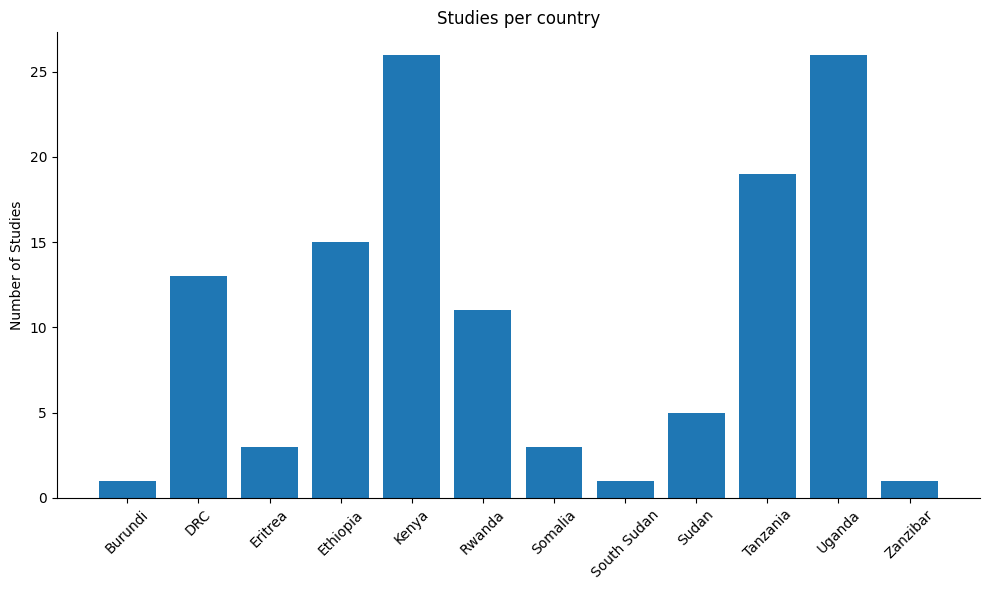

In [17]:
# Group by 'country' and calculate the number of unique 'pmid' for each country
country = df_combined.groupby("country")["pmid"].nunique()

# Convert the Series to a DataFrame (index is automatically set by the groupby operation)
country_df = pd.DataFrame(country)

# Plotting
plt.figure(figsize=(10, 6))
bars = plt.bar(country_df.index, country_df["pmid"],)

sns.despine(top=True, right=True)

# Adding labels and title
#plt.xlabel("Country")
plt.ylabel("Number of Studies")
plt.title("Studies per country")

# Show plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../results/paper_report.png", dpi=300, bbox_inches='tight')
plt.show()

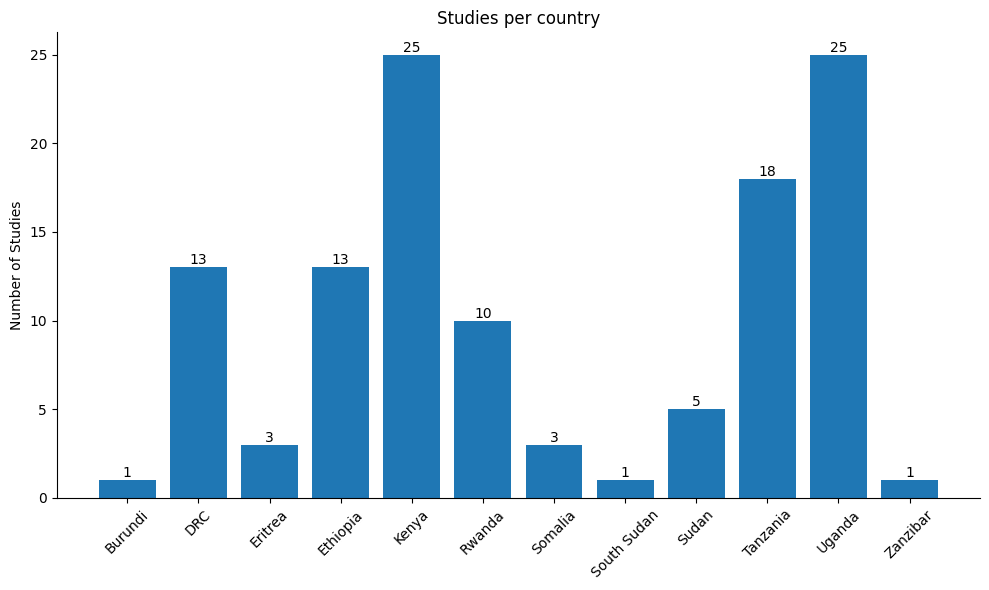

In [18]:
# Group by 'country' and calculate the number of unique 'pmid' for each country
country = validated_df.groupby("country")["pmid"].nunique()

# Convert the Series to a DataFrame (index is automatically set by the groupby operation)
country_df = pd.DataFrame(country)

# Plotting
plt.figure(figsize=(10, 6))
bars = plt.bar(country_df.index, country_df["pmid"],)

for bar in bars:
    yval = bar.get_height()  # Get the height (number of unique PMIDs) of each bar
    plt.text(bar.get_x() + bar.get_width() / 2, yval, int(yval), ha="center", va="bottom")  # Label the bar
    
sns.despine(top=True, right=True)

# Adding labels and title
#plt.xlabel("Country")
plt.ylabel("Number of Studies")
plt.title("Studies per country")

# Show plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../results/paper_report.png", dpi=300, bbox_inches='tight')
plt.show()

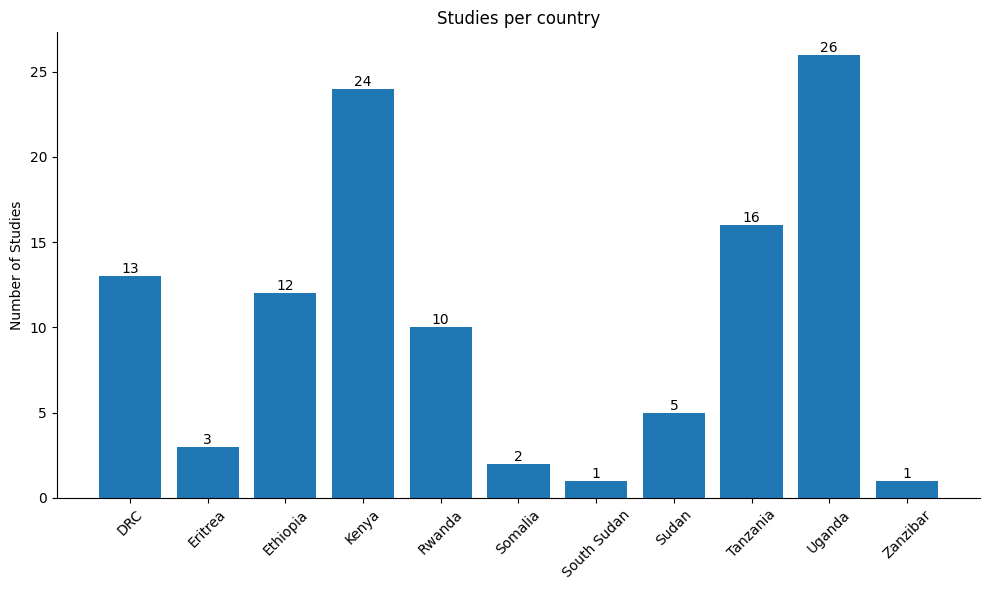

In [19]:
# Group by 'country' and calculate the number of unique 'pmid' for each country
country =nonval_df.groupby("country")["pmid"].nunique()

# Convert the Series to a DataFrame (index is automatically set by the groupby operation)
country_df = pd.DataFrame(country)

# Plotting
plt.figure(figsize=(10, 6))
bars = plt.bar(country_df.index, country_df["pmid"],)

for bar in bars:
    yval = bar.get_height()  # Get the height (number of unique PMIDs) of each bar
    plt.text(bar.get_x() + bar.get_width() / 2, yval, int(yval), ha="center", va="bottom")  # Label the bar
    
sns.despine(top=True, right=True)

# Adding labels and title
#plt.xlabel("Country")
plt.ylabel("Number of Studies")
plt.title("Studies per country")

# Show plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../results/paper_report.png", dpi=300, bbox_inches='tight')
plt.show()

In [20]:
validated_df[validated_df["country"] == "Kenya"]["pmid"].unique()


array(['36036611', '34615917', '25180240', '34152946', '32795367',
       '35266823', '26801909', '26392510', '25695257', '39103358',
       '38287365', '37452073', '36894982', '36100912', '31756512',
       '29582728', '29363453', '34111412', '10.2139/SSRN.4617870',
       '10.12688/wellcomeopenres.17656.1', '28535801', '39425178',
       '25367300', '27001814', '31591113'], dtype=object)

In [21]:
nonval_df[nonval_df["country"] == "Kenya"]["pmid"].unique()


array(['36036611', '34615917', '25180240', '34152946', '32795367',
       '35266823', '26801909', '26392510', '25695257', '39103358',
       '38287365', '37452073', '36894982', '36100912', '31756512',
       '29582728', '29363453', '34111412',
       '10.12688/Wellcomeopenres.17656.1', '28535801', '39425178',
       '31591113', '25367300', '27001814'], dtype=object)

In [22]:
validated_df[(validated_df["k13_validated_mutations"]=="A675V") & (validated_df["country"]=="Kenya")]

,pmid,year_pub,year_sample,country,region/province,town,participants_age,participants_age_unit,sample_size,first_line_act,...,k13_validated_mutations,type_of_mutation,mutation_frequency_(%),where_sequenced,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude
406,38287365,2024,2021,Kenya,Western Kenya,Kakamega,>4,years,123,AL,...,A675V,non-synonymous,3 (25),missing,raw counts,open,3.0,25.00,0.28422,34.75229
904,10.2139/SSRN.4617870,2023,2000-2007,Kenya,missing,missing,missing,missing,-,AL,...,A675V,non-synonymous,7.14,missing,percentage,open,NaN,7.14,-,-


In [23]:
papers_per_country_year = validated_df.groupby(["country", "year_pub"])["pmid"].nunique().reset_index()
papers_per_country_year.rename(columns={"pmid": "num_papers"}, inplace=True)


In [24]:
papers_per_country_year

,country,year_pub,num_papers
0,Burundi,2021,1
1,DRC,2014,2
2,DRC,2017,1
3,DRC,2018,1
4,DRC,2020,1
...,...,...,...
57,Uganda,2021,4
58,Uganda,2022,4
59,Uganda,2023,1
60,Uganda,2024,5


In [25]:
print(papers_per_country_year.head())


   country  year_pub  num_papers
0  Burundi      2021           1
1      DRC      2014           2
2      DRC      2017           1
3      DRC      2018           1
4      DRC      2020           1


In [26]:
pivot_table = papers_per_country_year.pivot(index="country", columns="year_pub", values="num_papers").fillna(0).astype(int)
pivot_table


year_pub,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
country,,,,,,,,,,,
Burundi,0,0,0,0,0,0,0,1,0,0,0
DRC,2,0,0,1,1,0,1,3,3,0,2
Eritrea,0,0,0,0,0,0,1,1,0,1,0
Ethiopia,1,2,0,1,0,1,0,1,1,2,4
Kenya,2,2,2,1,2,1,2,3,4,3,3
Rwanda,0,0,1,0,0,0,1,3,1,2,2
Somalia,0,0,0,0,0,1,0,1,0,1,0
South Sudan,0,0,0,0,0,0,0,0,0,1,0
Sudan,0,0,0,0,0,2,2,0,0,1,0


In [27]:
pivot_table.columns = pivot_table.columns.astype(int)
pivot_table

year_pub,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
country,,,,,,,,,,,
Burundi,0,0,0,0,0,0,0,1,0,0,0
DRC,2,0,0,1,1,0,1,3,3,0,2
Eritrea,0,0,0,0,0,0,1,1,0,1,0
Ethiopia,1,2,0,1,0,1,0,1,1,2,4
Kenya,2,2,2,1,2,1,2,3,4,3,3
Rwanda,0,0,1,0,0,0,1,3,1,2,2
Somalia,0,0,0,0,0,1,0,1,0,1,0
South Sudan,0,0,0,0,0,0,0,0,0,1,0
Sudan,0,0,0,0,0,2,2,0,0,1,0


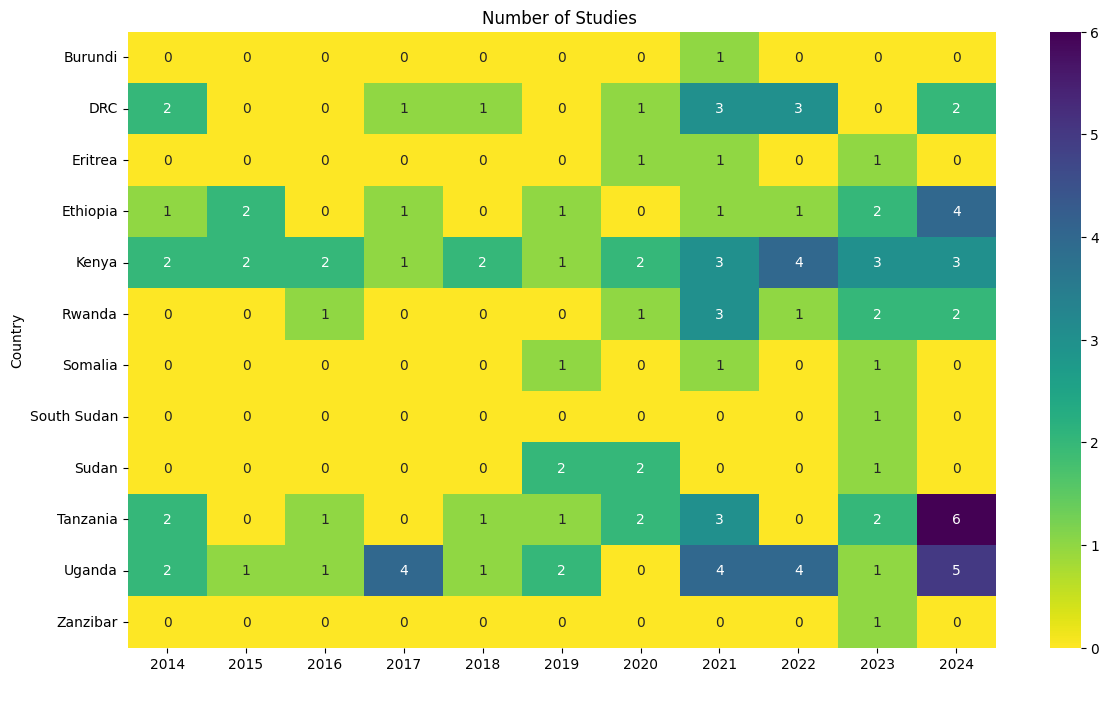

In [28]:
plt.figure(figsize=(14, 8))
sns.heatmap(pivot_table, cmap="viridis_r", annot=True, fmt="d")
plt.title("Number of Studies ")
plt.xlabel(" ")
plt.ylabel("Country")
#plt.savefig("heatmap")
plt.show()


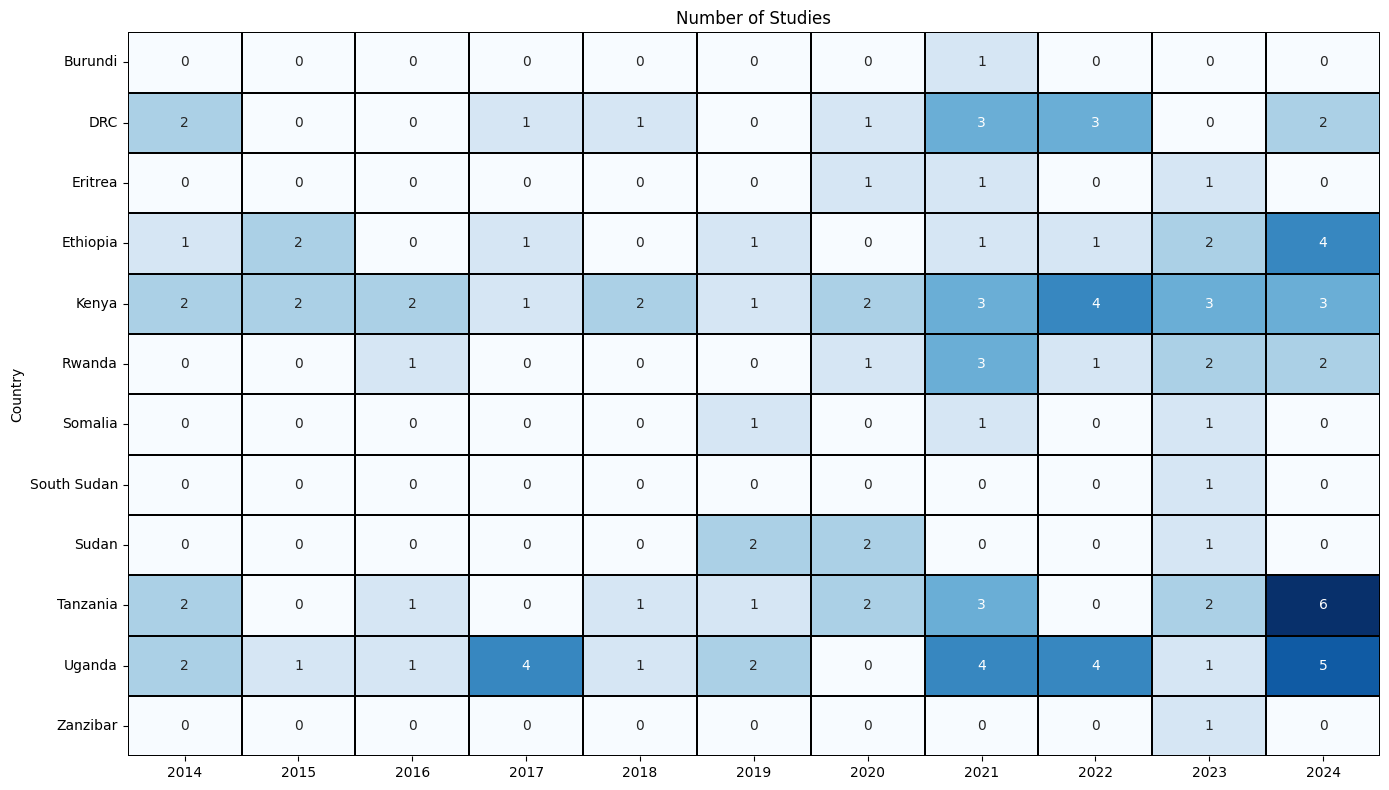

In [29]:
plt.figure(figsize=(14, 8))
sns.heatmap(
    pivot_table,
    annot=True,
    fmt="d",              # Display as integers
    cmap="Blues",         # Monochrome grayscale
    cbar=False,           # Hide the color bar
    linewidths=0.05,       # Optional: thin borders between cells
    linecolor='black' # Optional: border color
)

plt.title("Number of Studies")
plt.xlabel("")            # Optional: hide x-axis label
plt.ylabel("Country")

plt.tight_layout()
plt.savefig("../heatmap.png", dpi=300)
plt.show()


In [30]:
validated_df[(validated_df["country"]=="Tanzania") & (validated_df["year_pub"]==2024)]["pmid"].nunique()

6

In [31]:
print(plt.colormaps())

['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted_r', 'turbo_r', 'Blues_r', 'BrBG_r', '

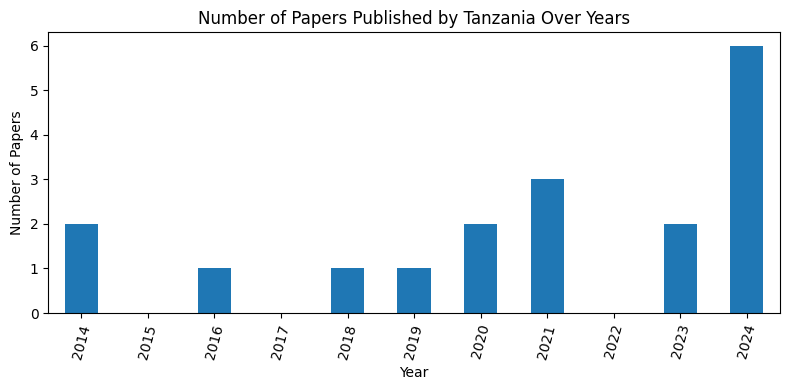

In [32]:
pivot_table.loc["Tanzania"].plot(kind="bar", figsize=(8, 4))
plt.title("Number of Papers Published by Tanzania Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Papers")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


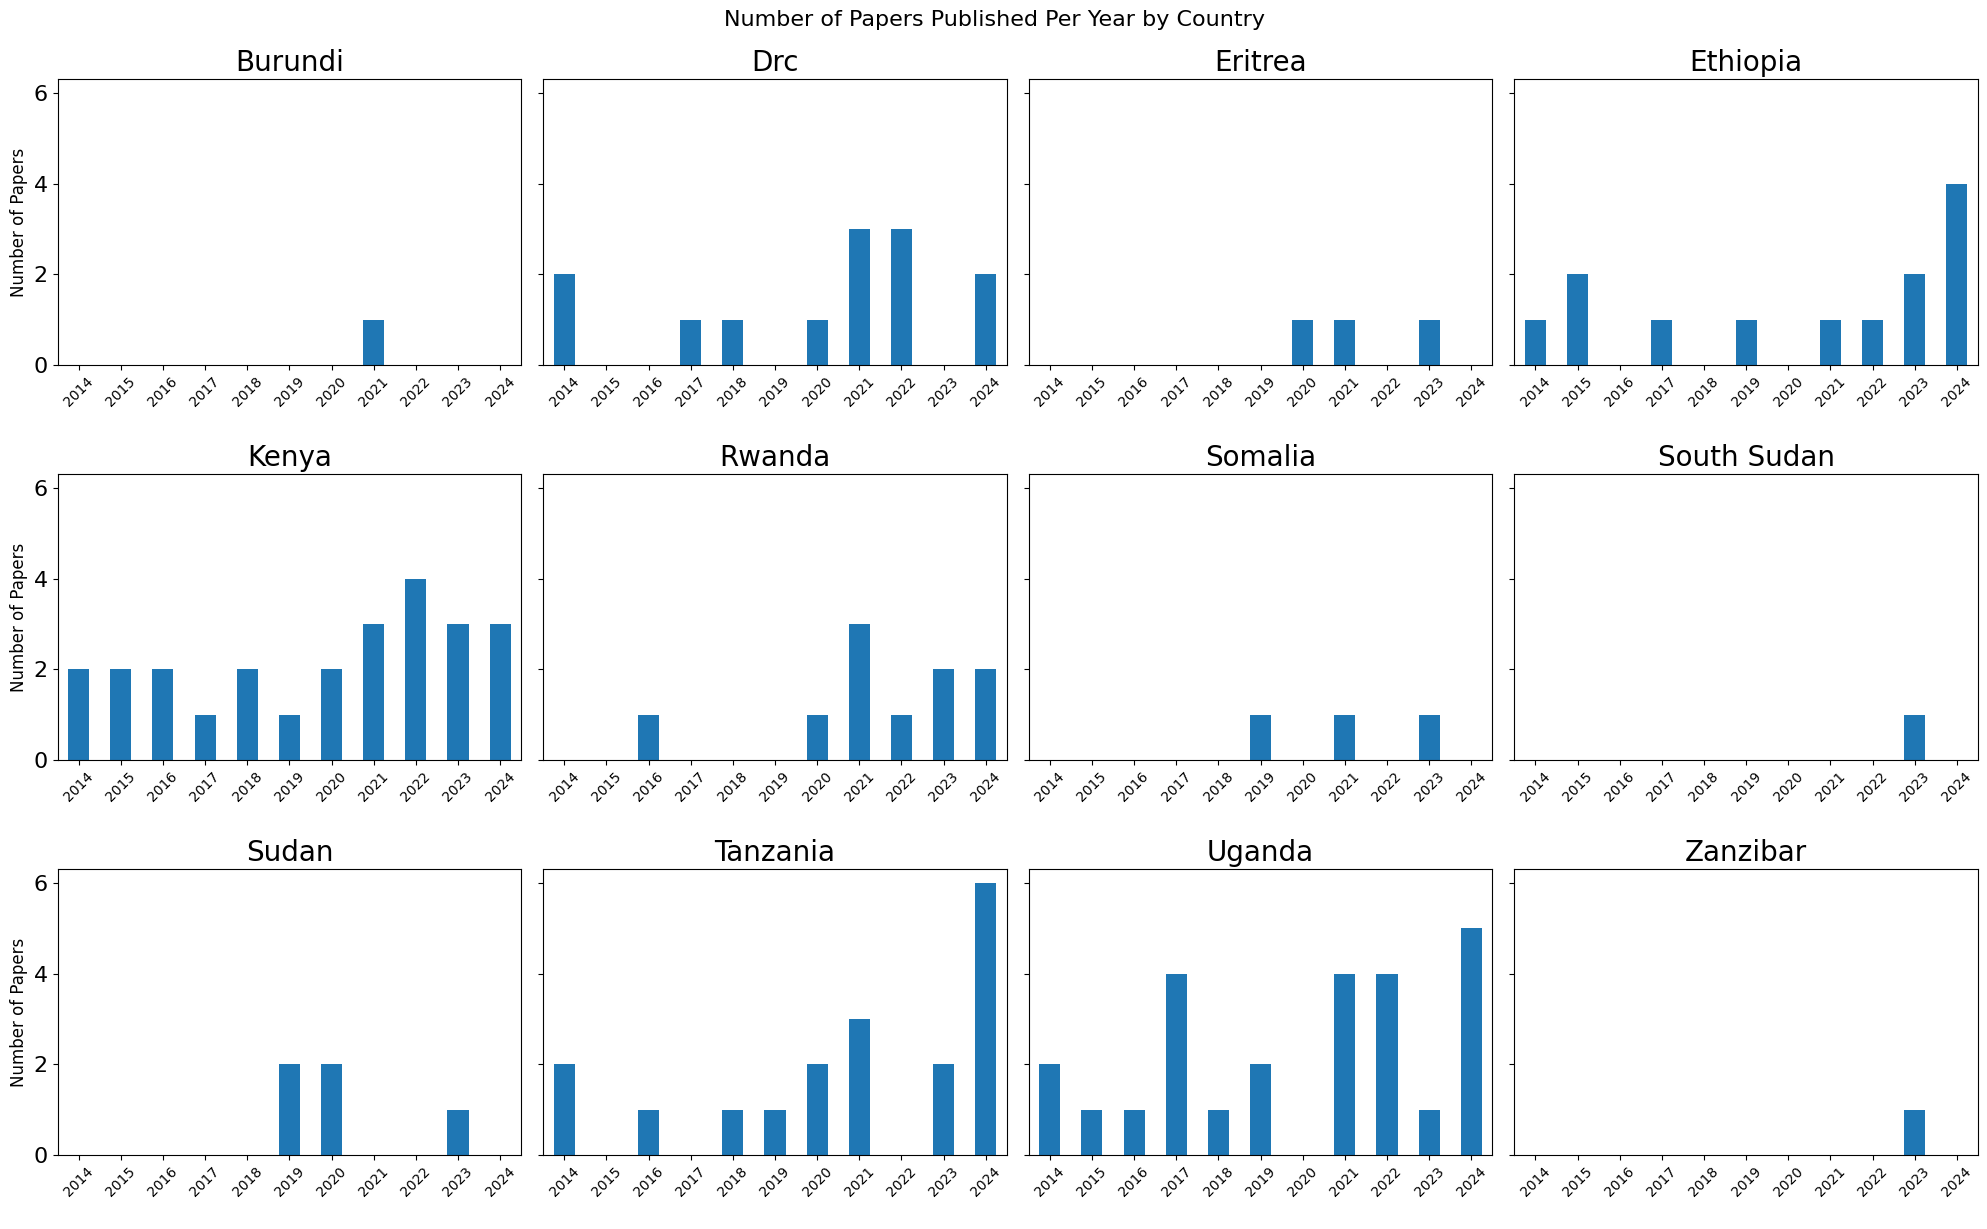

In [33]:
# Set number of countries and layout for subplots
countries = pivot_table.index.tolist()
n_countries = len(countries)

# Determine subplot grid size (e.g., 3 columns)
ncols = 4
nrows = -(-n_countries // ncols)  # Ceiling division

# Create subplots
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 5, nrows *4), sharey=True)
axes = axes.flatten()  # Flatten in case it's 2D

# Plot each country's data
for i, country in enumerate(countries):
    ax = axes[i]
    pivot_table.loc[country].plot(kind="bar", ax=ax)
    ax.set_title(country.title(), fontsize=20)
    ax.set_xlabel(" ")
    ax.set_ylabel("Number of Papers", fontsize=12)
    ax.tick_params(axis='x', rotation=45, labelsize=10)
    ax.tick_params(axis="y", labelsize=16)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Number of Papers Published Per Year by Country", fontsize=16, y=1.02)
plt.savefig("../results/papers_per_country.png", dpi=300)
plt.savefig("../results/papers_per_country.pdf")
plt.show()

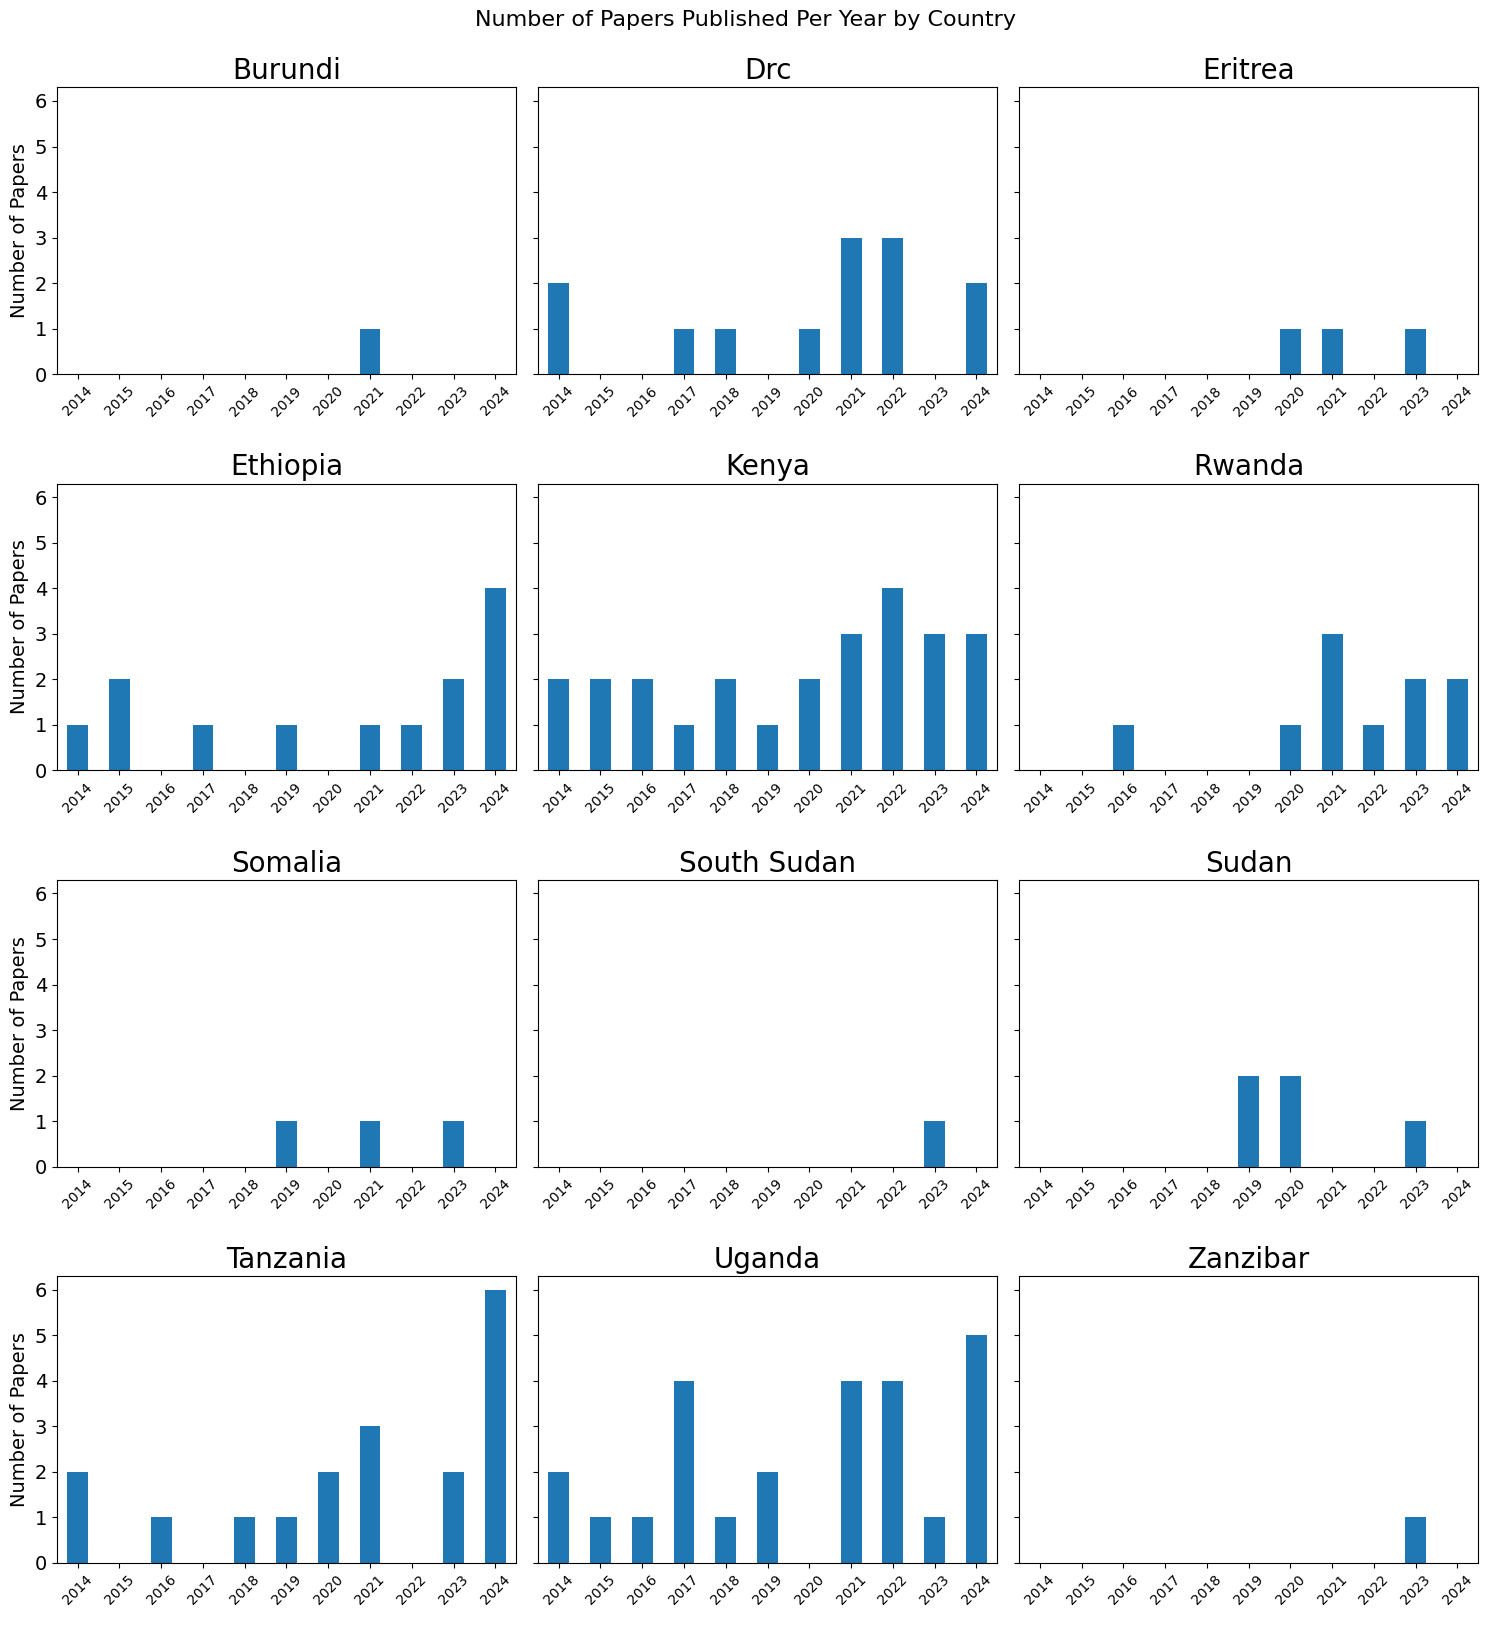

In [34]:
# Prepare country list and subplot grid layout
countries = pivot_table.index.tolist()
n_countries = len(countries)

ncols = 3
nrows = -(-n_countries // ncols)  # Ceiling division

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 5, nrows * 4), sharey=True)
axes = axes.flatten()

# Plot for each country
for i, country in enumerate(countries):
    ax = axes[i]
    data = pivot_table.loc[country]
    bars = data.plot(kind="bar", ax=ax)

    ax.set_title(country.title(), fontsize=20)
    ax.set_xlabel(" ")
    ax.set_ylabel("Number of Papers", fontsize=14)
    ax.tick_params(axis='x', rotation=45, labelsize= 10)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_xticklabels([str(int(label.get_text())) for label in ax.get_xticklabels()])
    ax.set
    

    # Annotate bars with values
    #for bar in bars.patches:
     #   height = bar.get_height()
      #  if height > 0:
       #     ax.annotate(f'{int(height)}',
        #                (bar.get_x() + bar.get_width() / 2, height),
         #               ha='center', va='bottom', fontsize=8)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Number of Papers Published Per Year by Country", fontsize=16, y=1.02)
plt.savefig("temproral by country.png")
plt.show()


In [35]:
validated_df[validated_df["country"]=="Tanzania"]["pmid"].unique()

array(['39159629', '25180240', '34152946', '30898164', '38746440',
       '34270452', '32103124', '38876161', '38352311',
       '10.2139/SSRN.4617870', '34279219', '39159633', '37986920',
       '38461239', '33107096', '30333022', '25367300', '27001814'],
      dtype=object)

In [36]:
df_combined.columns

Index(['pmid', 'year_pub', 'year_sample', 'country', 'region/province', 'town',
       'sample_size', 'samples_genotyped', 'other_k13_mutations', 'Frequency',
       'data_extraction_comments', 'journal_access', 'raw_count',
       'percentage_frequency', 'latitude', 'longitude',
       'k13_validated_mutations', 'type_of_mutation',
       'mutation_frequency_(%)'],
      dtype='object')

In [37]:
# Step 1: Copy relevant columns
df = df_combined[["year_pub",'k13_validated_mutations', "other_k13_mutations",
                  'mutation_frequency (%)', "Frequency"]].copy()

# Step 2: Extract numerator and denominator from frequency strings
# For validated mutations
validated = df[df['k13_validated_mutations'].notna()].copy()
validated[["val_num", "val_den"]] = validated['mutation_frequency (%)'].str.extract(r'(\d+)\s*/\s*(\d+)').astype(float)

# For non-validated mutations
non_validated = df[df["other_k13_mutations"].notna()].copy()
non_validated[["nonval_num", "nonval_den"]] = non_validated["Frequency"].str.extract(r'(\d+)\s*/\s*(\d+)').astype(float)

# Step 3: Group by year and sum numerator and denominator
val_grouped = validated.groupby("year_pub")[["val_num", "val_den"]].sum()
nonval_grouped = non_validated.groupby("year_pub")[["nonval_num", "nonval_den"]].sum()

# Step 4: Calculate total frequency per year
val_grouped["validated_freq"] = val_grouped["val_num"] / val_grouped["val_den"]
nonval_grouped["non_validated_freq"] = nonval_grouped["nonval_num"] / nonval_grouped["nonval_den"]

# Step 5: Merge the two frequency DataFrames on year
freq_df = pd.merge(val_grouped[["validated_freq"]], 
                   nonval_grouped[["non_validated_freq"]], 
                   left_index=True, right_index=True, how="outer").reset_index()

# Step 6: Plot side-by-side bars
x = np.arange(len(freq_df["year_pub"]))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, freq_df["validated_freq"], width, label="Validated", color="red")
bars2 = ax.bar(x + width/2, freq_df["non_validated_freq"], width, label="Non-Validated", color="skyblue")

# Add percentage labels on top
for bar in bars1:
    height = bar.get_height()
    if not np.isnan(height):
        ax.annotate(f'{height:.1%}', 
                    xy=(bar.get_x() + bar.get_width()/2, height), 
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    if not np.isnan(height):
        ax.annotate(f'{height:.1%}', 
                    xy=(bar.get_x() + bar.get_width()/2, height), 
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

# Final touches
ax.set_xticks(x)
ax.set_xticklabels(freq_df["year_pub"], rotation=45)
ax.set_ylabel("Mutation Frequency")
ax.set_title("Average Frequency of Validated and Non-Validated Mutations by Year")
ax.legend()
plt.tight_layout()
plt.show()


KeyError: "['mutation_frequency (%)'] not in index"

# **Reading the version 6 excel**

In [38]:
validated_df1 = pd.read_excel("../K13_validated_v6.xlsx")
validated_df1

,pmid,year_pub,year_sample,country,region/province,town,participants_age,participants_age_unit,sample_size,first_line_act,...,type_of_mutation,mutation_frequency_(%),where_sequenced,other_k13_mutations,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude
0,34551228,2021,2015,Uganda,Northern-Uganda,Gulu,≥0.5,years,77,AL,...,non-synonymous,0,missing,-,raw counts,open,0.0,0.0,2.85604,32.43001
1,34551228,2021,2015,Uganda,Northern-Uganda,Gulu,≥0.5,years,77,AL,...,non-synonymous,0,missing,-,raw counts,open,0.0,0.0,2.85604,32.43001
2,34551228,2021,2016,Uganda,Northern-Uganda,Gulu,≥0.5,years,94,AL,...,non-synonymous,0,missing,-,raw counts,open,0.0,0.0,2.85604,32.43001
3,34551228,2021,2016,Uganda,Northern-Uganda,Gulu,≥0.5,years,94,AL,...,non-synonymous,3 (3.4),missing,-,raw counts,open,3.0,3.4,2.85604,32.43001
4,34551228,2021,2017,Uganda,Northern-Uganda,Gulu,≥0.5,years,101,AL,...,non-synonymous,0,missing,-,raw counts,open,0.0,0.0,2.85604,32.43001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1009,33864801,2021,NaN,Rwanda,Eastern Province,Rukara,6-59,months,88,-,...,non-synonymous,18(10),Rwanda,"P441L, C469F, G449A, V555A, R575K",raw counts,open,18.0,10.0,-1.7952,30.5068
1010,33864801,2021,NaN,Rwanda,Eastern Province,Rukara,6-59,months,88,-,...,non-synonymous,1(1),Rwanda,-,raw counts,open,1.0,1.0,-1.7952,30.5068
1011,33864801,2021,NaN,Rwanda,Kigali Province,Masaka,6-59,months,52,-,...,non-synonymous,10(20),Rwanda,-,raw counts,open,10.0,20.0,-1.99627,30.19205
1012,33864801,2021,NaN,Rwanda,Kigali Province,Masaka,6-59,months,52,-,...,non-synonymous,1(2),Rwanda,-,raw counts,open,1.0,2.0,-1.99627,30.19205


In [39]:
validated_df1["country"].unique()

array(['Uganda', 'DRC', 'Kenya', 'Ethiopia', 'Tanzania', 'Sudan',
       'Rwanda', 'Eritrea', 'Zanzibar', 'Somalia', 'Burundi',
       'South Sudan'], dtype=object)

In [40]:
# Fix country name mismatches manually (example)
country_name_map = {
     'DRC' : "Dem. Rep. Congo"
}

# Standardize names
validated_df1['country'] = validated_df1['country'].replace(country_name_map)


In [41]:
validated_df1["country"].unique()

array(['Uganda', 'Dem. Rep. Congo', 'Kenya', 'Ethiopia', 'Tanzania',
       'Sudan', 'Rwanda', 'Eritrea', 'Zanzibar', 'Somalia', 'Burundi',
       'South Sudan'], dtype=object)

In [42]:
validated_df1.columns

Index(['pmid', 'year_pub', 'year_sample', 'country', 'region/province', 'town',
       'participants_age', 'participants_age_unit', 'sample_size',
       'first_line_act', 'genotyping_assay', 'study_population',
       'samples_genotyped', 'k13_validated_mutations', 'type_of_mutation',
       'mutation_frequency_(%)', 'where_sequenced', 'other_k13_mutations',
       'data_extraction_comments', 'journal_access', 'raw_count',
       'percentage_frequency', 'latitude', 'longitude'],
      dtype='object')

In [43]:
validated_df1["k13_validated_mutations"].unique()

array(['C469Y', 'A675V', '-', 'R622I', 'C580Y', 'I543T', 'R539T', 'Y493H',
       'M476I', 'R561H', 'P553L', 'P574L', '-\t'], dtype=object)

In [44]:
mutation_map={
    "561H" : "R561H",
    "675V" : "A675V",   
    
}

validated_df1["k13_validated_mutations"] = validated_df1["k13_validated_mutations"].replace(mutation_map)

In [45]:
validated_df1[validated_df1["country"]=="Sudan"]

,pmid,year_pub,year_sample,country,region/province,town,participants_age,participants_age_unit,sample_size,first_line_act,...,type_of_mutation,mutation_frequency_(%),where_sequenced,other_k13_mutations,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude
85,31034031,2019,2015-2016,Sudan,South East Sudan,"Damazin, blue nile estate",missing,missing,31,AS+SP,...,-,0,macrogen,A621V,none,closed,NaN,NaN,11.8074,34.3656
359,32070355,2020,2015-2016,Sudan,South East Sudan,Damazin,missing,missing,130,AS+SP,...,-,0,"Wellcome Sanger Institute, UK",F375S,none,open,NaN,NaN,11.8074,34.3656
360,32070355,2020,2015-2016,Sudan,South East Sudan,Damazin,missing,missing,130,AS+SP,...,-,0,"Wellcome Sanger Institute, UK",K378R,none,open,NaN,NaN,11.8074,34.3656
361,32070355,2020,2015-2016,Sudan,South East Sudan,Damazin,missing,missing,130,AS+SP,...,-,0,"Wellcome Sanger Institute, UK",D389N,none,open,NaN,NaN,11.8074,34.3656
362,32070355,2020,2015-2016,Sudan,South East Sudan,Damazin,missing,missing,130,AS+SP,...,-,0,"Wellcome Sanger Institute, UK",K430K,none,open,NaN,NaN,11.8074,34.3656
363,32070355,2020,2015-2016,Sudan,South East Sudan,Damazin,missing,missing,130,AS+SP,...,-,0,"Wellcome Sanger Institute, UK",E433D,none,open,NaN,NaN,11.8074,34.3656
364,32070355,2020,2015-2016,Sudan,South East Sudan,Damazin,missing,missing,130,AS+SP,...,-,0,"Wellcome Sanger Institute, UK",P443P,none,open,NaN,NaN,11.8074,34.3656
365,32070355,2020,2015-2016,Sudan,South East Sudan,Damazin,missing,missing,130,AS+SP,...,-,0,"Wellcome Sanger Institute, UK",N594K,none,open,NaN,NaN,11.8074,34.3656
959,31369106,2019,2009-2016,Sudan,missing,missing,all ages,years,-,AS+SP,...,-,0,missing,-,none,closed,NaN,NaN,-,-
974,32817665,2020,2015-2017,Sudan,Central Sudan,Khartoum,missing,missing,158,AL,...,-,0,"Wellcome Sanger Institute, UK","K372K, K378R, D389H, K430E, E433D, L488L, A504...",raw counts,open,0.0,0.0,15.51026,32.54253


In [46]:
validated_df2=validated_df1.drop(columns=['participants_age', 'participants_age_unit', 'sample_size',
       'first_line_act', 'genotyping_assay', 'study_population','where_sequenced', 'other_k13_mutations',
       'data_extraction_comments', 'journal_access'])

In [47]:
df_cleaned = validated_df2.drop_duplicates(subset=["pmid", "year_pub", "k13_validated_mutations"])
df_cleaned


,pmid,year_pub,year_sample,country,region/province,town,samples_genotyped,k13_validated_mutations,type_of_mutation,mutation_frequency_(%),raw_count,percentage_frequency,latitude,longitude
0,34551228,2021,2015,Uganda,Northern-Uganda,Gulu,77,C469Y,non-synonymous,0,0.0,0.00,2.85604,32.43001
1,34551228,2021,2015,Uganda,Northern-Uganda,Gulu,77,A675V,non-synonymous,0,0.0,0.00,2.85604,32.43001
10,35703955,2022,missing,Dem. Rep. Congo,Central DRC,Kinshasa,118,-,-,0,0.0,0.00,-4.375,15.97
11,36036611,2022,2016-2017,Kenya,Western Kenya,Siaya,340,-,-,0,0.0,0.00,0.06116,34.28823
12,39136468,2024,2015-2023,Uganda,Eastern Uganda,"Tororo, Busia, Mbale",1112,C469Y,non-synonymous,6,6.0,0.54,0.41762,34.00421
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
998,25367300,2014,2013-2014,Dem. Rep. Congo,missing,Kishansa,82,-,-,0/82,0.0,0.00,-4.375,15.97
1002,27001814,2016,1998,Kenya,Kisii,Kisii,60,-,-,0/60,0.0,0.00,-0.75,34.83333
1004,31591113,2019,1995-1996,Kenya,Coastal Kenya,Kilifi,148,-,-,0,0.0,0.00,-3.563,39.644
1009,33864801,2021,NaN,Rwanda,Eastern Province,Rukara,82,R561H,non-synonymous,18(10),18.0,10.00,-1.7952,30.5068


In [48]:
df_cleaned = df_cleaned[df_cleaned["k13_validated_mutations"].notna()]  # removes real NaN
df_cleaned = df_cleaned[df_cleaned["k13_validated_mutations"] != "-"]   # removes "-"
df_cleaned.head(30)

,pmid,year_pub,year_sample,country,region/province,town,samples_genotyped,k13_validated_mutations,type_of_mutation,mutation_frequency_(%),raw_count,percentage_frequency,latitude,longitude
0,34551228,2021,2015,Uganda,Northern-Uganda,Gulu,77,C469Y,non-synonymous,0,0.0,0.00,2.85604,32.43001
1,34551228,2021,2015,Uganda,Northern-Uganda,Gulu,77,A675V,non-synonymous,0,0.0,0.00,2.85604,32.43001
12,39136468,2024,2015-2023,Uganda,Eastern Uganda,"Tororo, Busia, Mbale",1112,C469Y,non-synonymous,6,6.0,0.54,0.41762,34.00421
13,39136468,2024,2015-2023,Uganda,Eastern Uganda,"Tororo, Busia, Mbale",1112,A675V,non-synonymous,5,5.0,0.45,0.41762,34.00421
15,26483118,2015,2013-2014,Ethiopia,(Amhara Regional State)Northwest,Aykel,15,R622I,non-synonymous,1(6.7),1.0,6.70,12.54787,37.06321
21,29718283,2018,2013-2014,Dem. Rep. Congo,missing,missing,339,C580Y,non-synonymous,0,0.0,0.00,-,-
22,29718283,2018,2013-2014,Dem. Rep. Congo,missing,missing,331,I543T,non-synonymous,0,0.0,0.00,-,-
23,29718283,2018,2013-2014,Dem. Rep. Congo,missing,missing,331,R539T,non-synonymous,0,0.0,0.00,-,-
24,29718283,2018,2013-2014,Dem. Rep. Congo,missing,missing,331,Y493H,non-synonymous,0,0.0,0.00,-,-
25,29718283,2018,2013-2014,Dem. Rep. Congo,missing,missing,331,M476I,non-synonymous,0,0.0,0.00,-,-


In [49]:
print(plt.colormaps)

ColormapRegistry; available colormaps:
'magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted

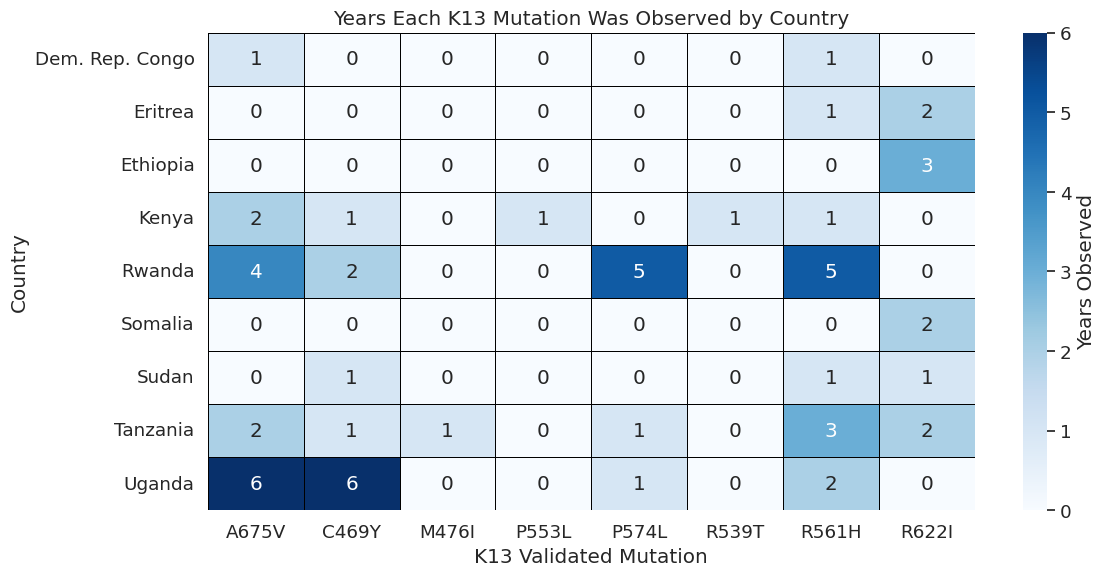

In [50]:
# Assuming your DataFrame is named `df`
# Step 1: Filter out rows with zero percentage frequency
df_filtered = validated_df2[validated_df2['percentage_frequency'] > 0]

# Step 2: Count the number of years each mutation was observed in each country
# Use drop_duplicates to avoid counting the same mutation in the same year more than once
df_unique = df_filtered.drop_duplicates(subset=['country', 'k13_validated_mutations', 'year_pub'])
df_unique = df_unique[df_unique["k13_validated_mutations"] != "-"]
heatmap_data = df_unique.groupby(['country', 'k13_validated_mutations']).size().unstack(fill_value=0)

# Step 3: Plot the heatmap
plt.figure(figsize=(12, 6))
sns.set(font_scale=1.2)

sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="Blues", linewidths=0.5, linecolor="black", cbar_kws={'label': 'Years Observed'})

plt.title("Years Each K13 Mutation Was Observed by Country")
plt.xlabel("K13 Validated Mutation")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


In [51]:
validated_df2[validated_df2["pmid"]== 36289202]

,pmid,year_pub,year_sample,country,region/province,town,samples_genotyped,k13_validated_mutations,type_of_mutation,mutation_frequency_(%),raw_count,percentage_frequency,latitude,longitude


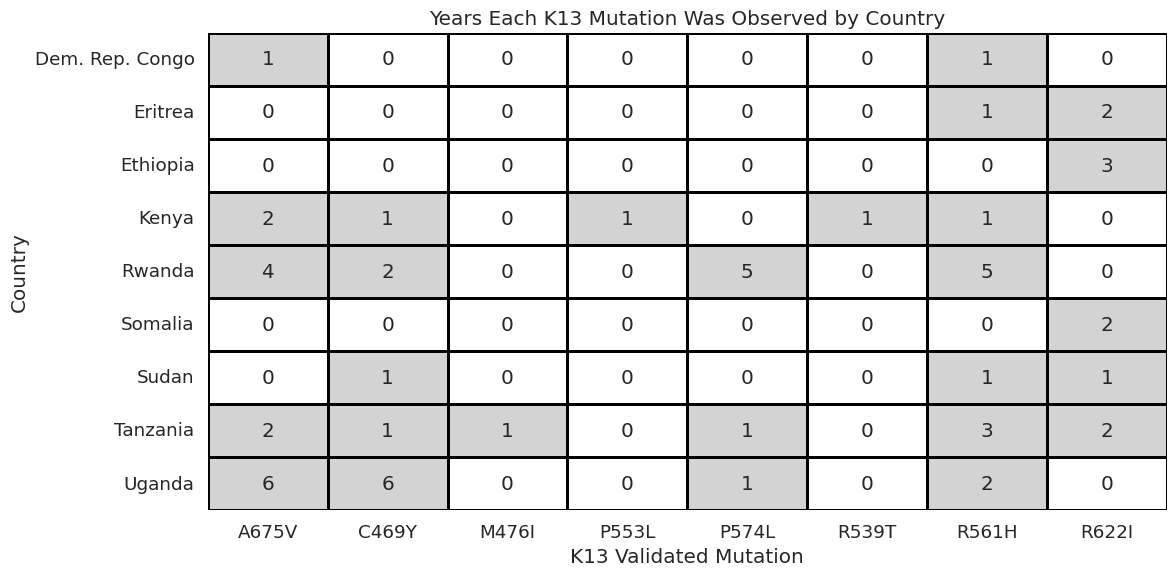

In [52]:
# Step 1: Filter out rows with zero percentage frequency
df_filtered = validated_df2[validated_df2['percentage_frequency'] > 0]

# Step 2: Remove duplicates and exclude a specific PMID
df_unique = df_filtered.drop_duplicates(subset=['country', 'k13_validated_mutations', 'year_pub'])
df_unique = df_unique[df_unique["k13_validated_mutations"] != "-"]

# Step 3: Create heatmap data
heatmap_data = df_unique.groupby(['country', 'k13_validated_mutations']).size().unstack(fill_value=0)

# Step 4: Create a binary colormap: white for 0, grey for >0
colors = ["white", "lightgrey"]
cmap = mcolors.ListedColormap(colors)

# Normalize: 0 → 0, all others → 1
bounds = [0, 0.5, heatmap_data.values.max() + 1]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Step 5: Plot the heatmap
plt.figure(figsize=(12, 6))
sns.set(font_scale=1.2)

sns.heatmap(heatmap_data, annot=True, fmt="d", cmap=cmap, norm=norm,
            linewidths=1.0, linecolor="black", cbar=False)  # cbar=False to remove irrelevant color bar

plt.title("Years Each K13 Mutation Was Observed by Country")
plt.xlabel("K13 Validated Mutation")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("../years_k13_observed.png", dpi=300)
plt.show()


In [53]:
df_unique["country"].unique()

array(['Uganda', 'Ethiopia', 'Tanzania', 'Kenya', 'Rwanda',
       'Dem. Rep. Congo', 'Somalia', 'Eritrea', 'Sudan'], dtype=object)

In [54]:
df_unique[(df_unique["k13_validated_mutations"]=="-") & (df_unique["country"]=="Uganda")]


,pmid,year_pub,year_sample,country,region/province,town,samples_genotyped,k13_validated_mutations,type_of_mutation,mutation_frequency_(%),raw_count,percentage_frequency,latitude,longitude


In [55]:
cols = ["k13_validated_mutations"]
validated_df1 = validated_df1[~validated_df1[cols].eq("-").any(axis=1)]


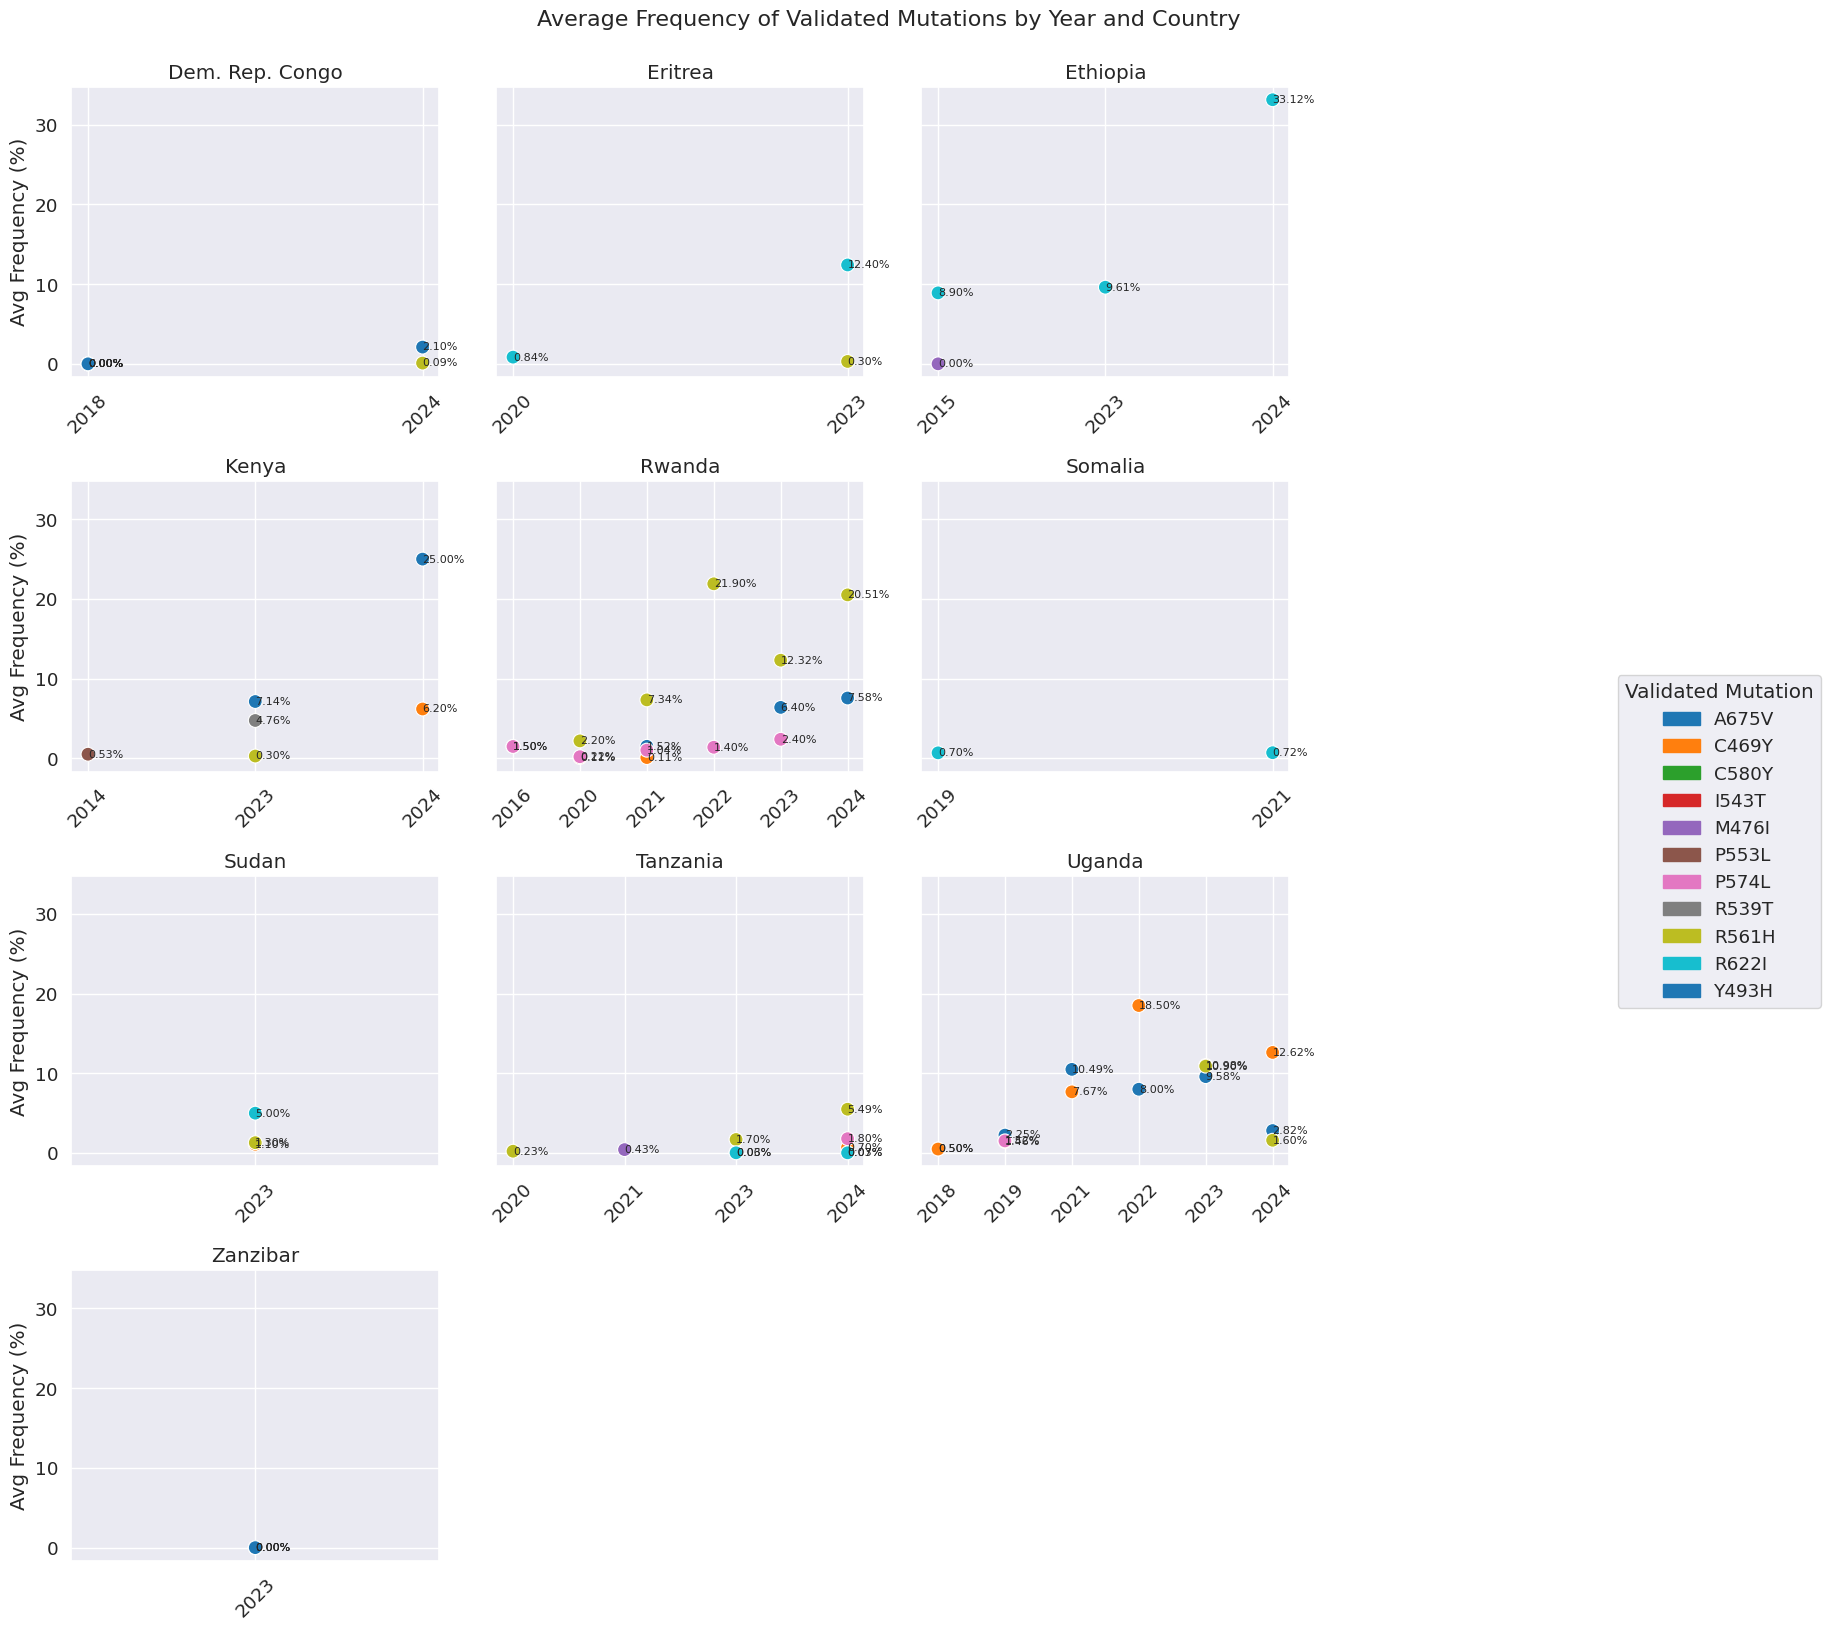

In [56]:
# Sample preprocessing (replace with your actual df_combined and preprocessing)
df = validated_df1[["country", "year_pub", "k13_validated_mutations", "percentage_frequency"]].copy()
df = df[df["k13_validated_mutations"].notna()]
df["percentage_frequency"] = pd.to_numeric(df["percentage_frequency"], errors='coerce')
df = df.dropna(subset=["percentage_frequency", "year_pub", "country"])

# Optional: Normalize mutation names (e.g., lowercase and strip)
df["k13_validated_mutations"] = df["k13_validated_mutations"].str.upper().str.strip()

grouped = df.groupby(["country", "year_pub", "k13_validated_mutations"])["percentage_frequency"].mean().reset_index()
grouped["year_pub"] = grouped["year_pub"].astype(int).astype(str)


countries = grouped["country"].unique()
n_countries = len(countries)
ncols = 3
nrows = -(-n_countries // ncols)

# Create global sorted unique mutation list for consistent ordering
mutations = sorted(grouped["k13_validated_mutations"].unique())

# Create a global palette dict mapping mutation -> color
palette_colors = sns.color_palette("tab10", n_colors=len(mutations))
palette_dict = dict(zip(mutations, palette_colors))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 6, nrows * 4), sharey=True)
axes = axes.flatten()

for i, country in enumerate(countries):
    ax = axes[i]
    country_df = grouped[grouped["country"] == country]

    # Scatterplot with larger dots (s=100 for size)
    sns.scatterplot(
        data=country_df,
        x="year_pub",
        y="percentage_frequency",
        hue="k13_validated_mutations",
        palette=palette_dict,
        ax=ax,
        legend=False,
        s=100  # increase marker size
    )

    # Add frequency labels next to dots
    for _, row in country_df.iterrows():
        ax.text(
            row["year_pub"], 
            row["percentage_frequency"], 
            f'{row["percentage_frequency"]:.2f}%', 
            fontsize=8, 
            ha='left', 
            va='center'
        )

    ax.set_title(country.title())
    ax.set_ylabel("Avg Frequency (%)")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=45)

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Create legend handles using the global palette dict
handles = [mpatches.Patch(color=palette_dict[m], label=m) for m in mutations]

# Adjust the figure to leave space for the legend on the right
fig.subplots_adjust(right=0.75)

# Place legend outside the plot
fig.legend(handles=handles, loc='center left', bbox_to_anchor=(0.9, 0.5), title="Validated Mutation")

plt.tight_layout(rect=[0, 0, 0.75, 1])  # leave space for legend
plt.suptitle("Average Frequency of Validated Mutations by Year and Country", fontsize=16, y=1.02)
plt.savefig("../results/frequency_k13-tables.png")
plt.show()


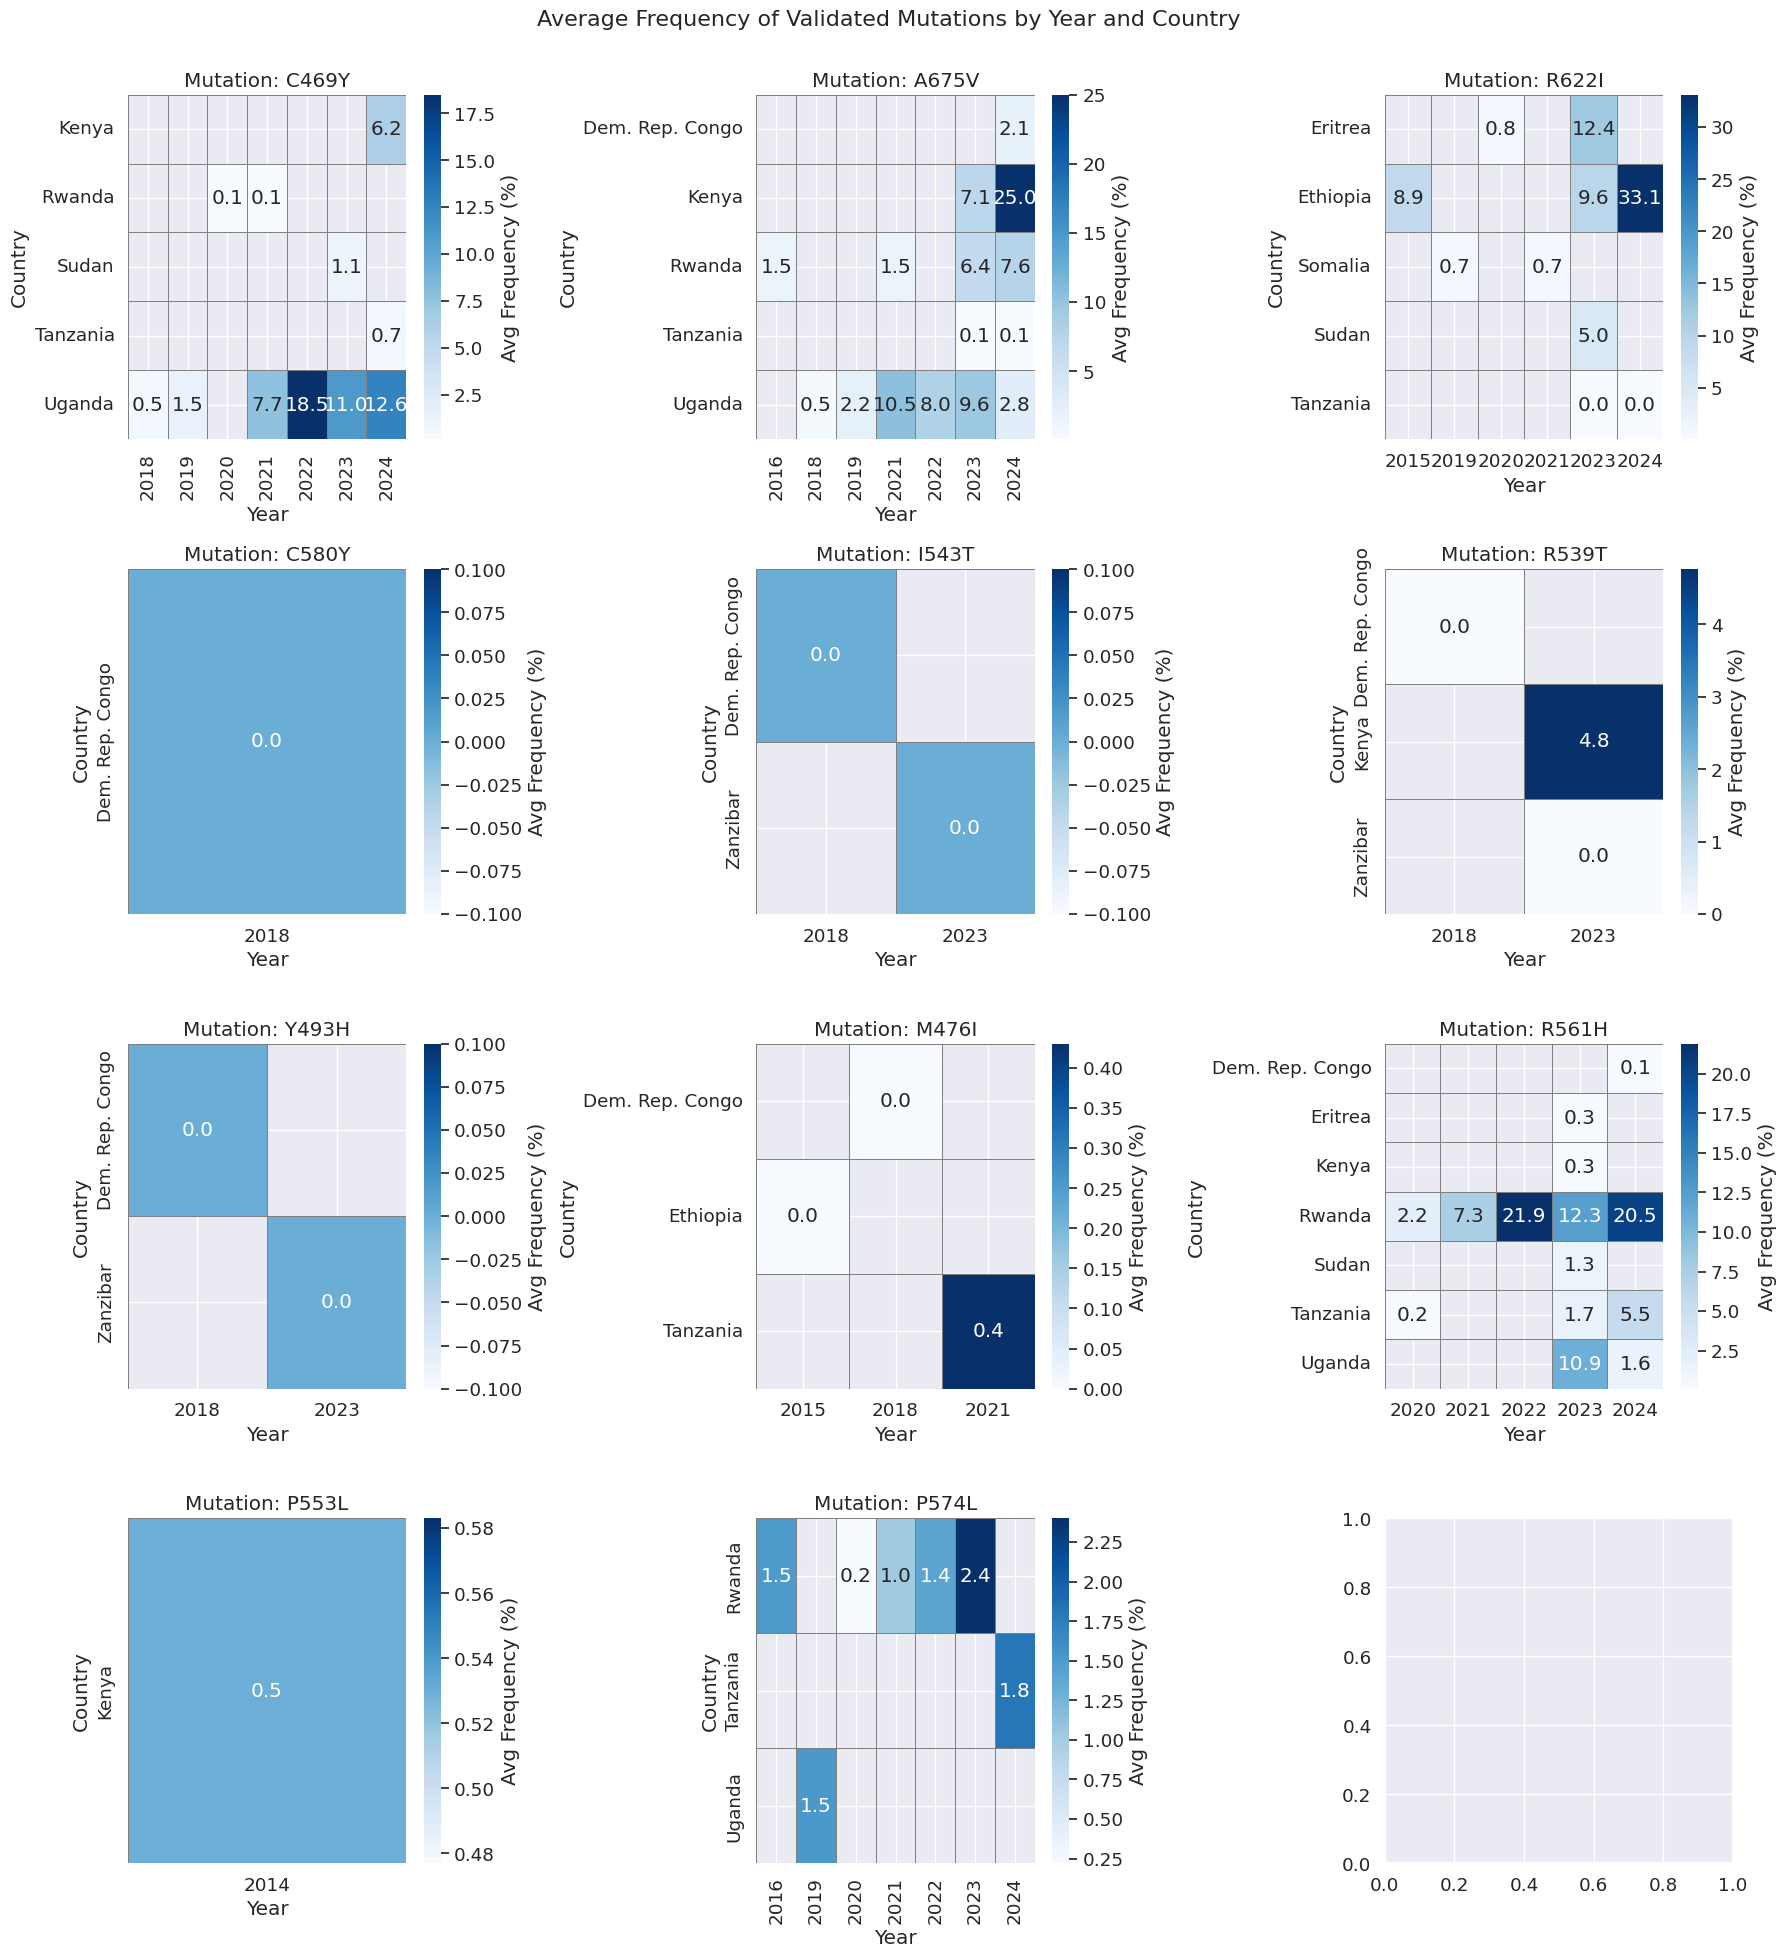

In [57]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------------------
# Preprocess
# ----------------------------------------
df = validated_df1[["country", "year_pub", "k13_validated_mutations", "percentage_frequency"]].copy()
df = df[df["k13_validated_mutations"].notna()]
df["percentage_frequency"] = pd.to_numeric(df["percentage_frequency"], errors='coerce')
df = df.dropna(subset=["percentage_frequency", "year_pub", "country"])
df["k13_validated_mutations"] = df["k13_validated_mutations"].str.upper().str.strip()
df["year_pub"] = df["year_pub"].astype(int)

# ----------------------------------------
# Get list of unique mutations
# ----------------------------------------
mutations = df["k13_validated_mutations"].unique()

# ----------------------------------------
# Plot one heatmap per mutation
# ----------------------------------------
ncols = 3
nrows = -(-len(mutations) // ncols)  # Ceiling division
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 6, nrows * 5), squeeze=False)

for idx, mutation in enumerate(mutations):
    ax = axes[idx // ncols][idx % ncols]
    df_mut = df[df["k13_validated_mutations"] == mutation]

    pivot = df_mut.pivot_table(
        index="country", columns="year_pub", values="percentage_frequency", aggfunc='mean'
    )

    sns.heatmap(
        pivot,
        cmap="Blues",
        annot=True,
        fmt=".1f",
        linewidths=0.5,
        linecolor='gray',
        cbar_kws={'label': 'Avg Frequency (%)'},
        ax=ax
    )
    ax.set_title(f"Mutation: {mutation}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Country")

# ----------------------------------------
# Final layout
# ----------------------------------------
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.suptitle("Average Frequency of Validated Mutations by Year and Country", fontsize=16)
plt.savefig("../results/Average_Frequency_of_Validated_Mutations.pdf")
plt.savefig("../results/Average_Frequency_of_Validated_Mutations.png", dpi=400)
plt.show()


In [58]:
del(list)

NameError: name 'list' is not defined

In [ ]:
validated_df1.columns

In [ ]:
validated_df1[validated_df1["country"]=="S. Sudan"]['percentage_frequency']

In [ ]:
validated_df1["country"] = validated_df1["country"].replace({'South Sudan': 'S. Sudan'})

In [ ]:
world["NAME"].unique()

/tmp/ipykernel_25410/958386079.py:59: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world_centroids['centroid'] = world_centroids['geometry'].centroid


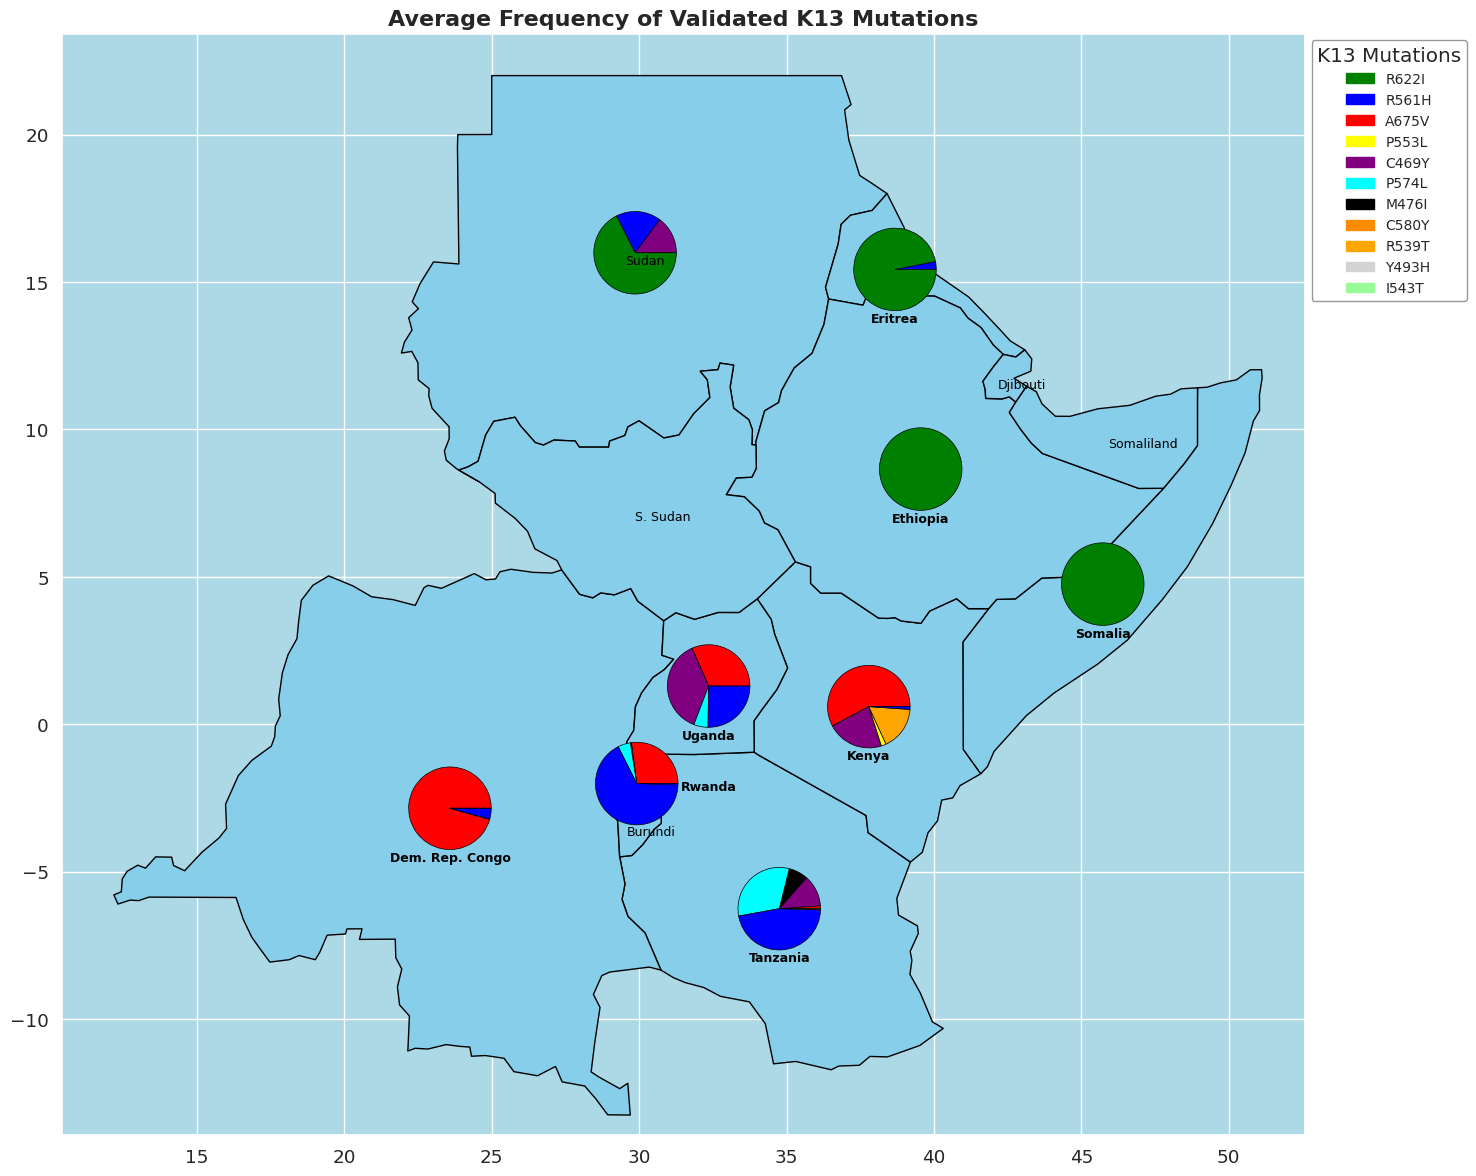

In [61]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
import matplotlib.patches as mpatches

# ----------------------------
# SETUP MUTATION COLORS
# ----------------------------
mutation_colors = {
    'R622I': 'green',
    'R561H': 'blue',
    'A675V': 'red',
    'P553L': 'yellow',
    'C469Y': 'purple',
    'P574L': 'cyan',
    'M476I': 'black',
    'C580Y': 'darkorange',
    'R539T': 'orange',
    'Y493H': 'lightgrey',
    'I543T': 'palegreen',
}

valid_mutations = list(mutation_colors.keys())

# ----------------------------
# CUSTOM LIST OF AFRICAN COUNTRIES
# ----------------------------
african_countries = [
    'Kenya', 'Uganda', 'Tanzania', 'Sudan', 'S. Sudan', 'Ethiopia', 'Rwanda', 'Dem. Rep. Congo',
    'Burundi', 'Djibouti', 'Eritrea', 'Somaliland', 'Somalia'
]

# ----------------------------
# CLEAN DATA
# ----------------------------
df_clean = validated_df1[
    validated_df1['k13_validated_mutations'].isin(valid_mutations)
].dropna(subset=['longitude', 'latitude', 'percentage_frequency'])

# ----------------------------
# GROUP BY COUNTRY & MUTATION: average frequency
# ----------------------------
freq_per_mutation_country = (
    df_clean.groupby(['country', 'k13_validated_mutations'])['percentage_frequency']
    .mean()
    .reset_index()
)

# ----------------------------
# LOAD WORLD MAP & FILTER COUNTRIES
# ----------------------------
world = gpd.read_file('../ne_110m_admin_0_map_units/ne_110m_admin_0_map_units.shp')
world_filtered = world[world['NAME'].isin(african_countries)]

# ----------------------------
# GET CENTROIDS FOR COUNTRY LABELING
# ----------------------------
world_centroids = world_filtered[['NAME', 'geometry']].copy()
world_centroids['centroid'] = world_centroids['geometry'].centroid
world_centroids['longitude'] = world_centroids['centroid'].x
world_centroids['latitude'] = world_centroids['centroid'].y
world_centroids = world_centroids.rename(columns={'NAME': 'country'})

# ----------------------------
# MERGE frequencies with centroid coords
# ----------------------------
coords = world_centroids[['country', 'latitude', 'longitude']]
plot_data = freq_per_mutation_country.merge(coords, on='country', how='inner')

# ----------------------------
# FUNCTION TO DRAW PROPORTIONAL PIES
# ----------------------------
def draw_proportional_pie(ax, x, y, mutations, frequencies, radius=1):
    total = sum(frequencies)
    if total == 0:
        return
    start_angle = 0
    for mut, freq in zip(mutations, frequencies):
        angle = 360 * (freq / total)
        wedge = Wedge(
            center=(x, y),
            r=radius,
            theta1=start_angle,
            theta2=start_angle + angle,
            facecolor=mutation_colors.get(mut, 'gray'),
            edgecolor='black',
            lw=0.5
        )
        ax.add_patch(wedge)
        start_angle += angle

# ----------------------------
# DRAW THE MAP AND PIES
# ----------------------------
fig, ax = plt.subplots(figsize=(15, 12))
world_filtered.plot(ax=ax, color='skyblue', edgecolor='black')
fig.patch.set_facecolor('white')  # Set figure background to white
ax.set_facecolor('lightblue') 

# Draw pie charts
for country in plot_data['country'].unique():
    country_data = plot_data[plot_data['country'] == country]
    muts = country_data['k13_validated_mutations'].tolist()
    freqs = country_data['percentage_frequency'].tolist()
    lat = country_data['latitude'].iloc[0]
    lon = country_data['longitude'].iloc[0]

    draw_proportional_pie(ax, lon, lat, muts, freqs, radius=1.4)

# ----------------------------
# FINAL TOUCHES
# ----------------------------
ax.set_aspect('equal', adjustable='datalim')
ax.autoscale(enable=False)

# Centered on East/Central Africa
ax.set_xlim(20, 43)
ax.set_ylim(-12, 21.5)

# Legend
legend_handles = [mpatches.Patch(color=color, label=mut) for mut, color in mutation_colors.items()]
legend = ax.legend(handles=legend_handles, title='K13 Mutations',
                   loc='upper left', bbox_to_anchor=(1, 1),
                   borderaxespad=0.5, fontsize=10)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('gray')

# Annotate country names with specific styles
# Annotate country names with specific styles
exclude_countries = ['S. Sudan', 'Sudan', 'Burundi', 'Somaliland', 'Djibouti']

for _, row in coords.iterrows():
    country = row['country']
    x, y = row['longitude'], row['latitude']

    if country == 'Rwanda':
        # Side label with dashed leader line
        label_x = x + 1.5  # shift right
        label_y = y - 0.1  # slight vertical shift
        ax.annotate(
            country,
            xy=(x, y),
            xytext=(label_x, label_y),
            textcoords="data",
            fontsize=9,
            color='black',
            ha='left',
            weight="bold",
            va='center',
            arrowprops=dict(
                arrowstyle='-',
                linestyle='dashed',
                color='black',
                lw=0.5
            )
        )
    elif country in exclude_countries:
        ax.annotate(
            country,
            xy=(x, y),
            xytext=(-7, -8),
            textcoords="offset points",
            fontsize=9,
            color='black'
        )
    else:
        ax.annotate(
            country,
            xy=(x, y),
            xytext=(0, -38),
            textcoords="offset points",
            ha='center',
            fontsize=9,
            color='black',
            weight='bold'
        )

plt.title('Average Frequency of Validated K13 Mutations', fontsize=16, weight='bold')
plt.tight_layout()
plt.savefig("../results/validated_mutations_africa_subset.png", dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_25410/3149466545.py:59: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world_centroids['centroid'] = world_centroids['geometry'].centroid


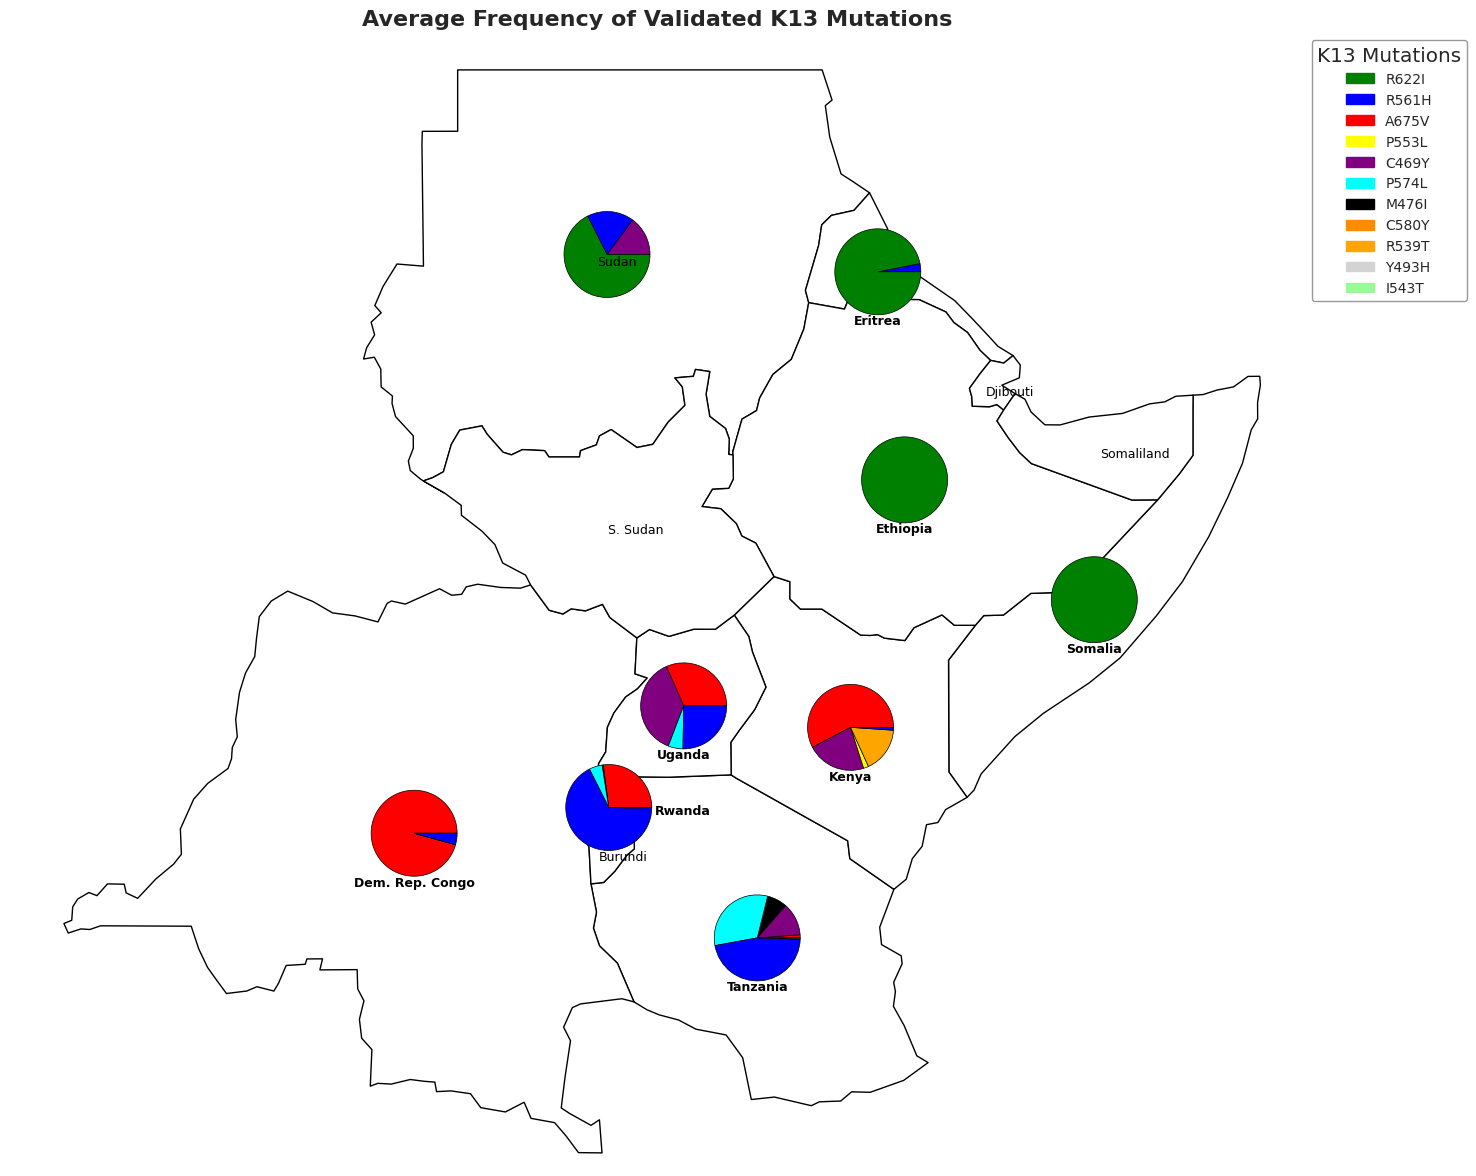

In [62]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
import matplotlib.patches as mpatches

# ----------------------------
# SETUP MUTATION COLORS
# ----------------------------
mutation_colors = {
    'R622I': 'green',
    'R561H': 'blue',
    'A675V': 'red',
    'P553L': 'yellow',
    'C469Y': 'purple',
    'P574L': 'cyan',
    'M476I': 'black',
    'C580Y': 'darkorange',
    'R539T': 'orange',
    'Y493H': 'lightgrey',
    'I543T': 'palegreen',
}

valid_mutations = list(mutation_colors.keys())

# ----------------------------
# CUSTOM LIST OF AFRICAN COUNTRIES
# ----------------------------
african_countries = [
    'Kenya', 'Uganda', 'Tanzania', 'Sudan', 'S. Sudan', 'Ethiopia', 'Rwanda', 'Dem. Rep. Congo',
    'Burundi', 'Djibouti', 'Eritrea', 'Somaliland', 'Somalia'
]

# ----------------------------
# CLEAN DATA
# ----------------------------
df_clean = validated_df1[
    validated_df1['k13_validated_mutations'].isin(valid_mutations)
].dropna(subset=['longitude', 'latitude', 'percentage_frequency'])

# ----------------------------
# GROUP BY COUNTRY & MUTATION: average frequency
# ----------------------------
freq_per_mutation_country = (
    df_clean.groupby(['country', 'k13_validated_mutations'])['percentage_frequency']
    .mean()
    .reset_index()
)

# ----------------------------
# LOAD WORLD MAP & FILTER COUNTRIES
# ----------------------------
world = gpd.read_file('../ne_110m_admin_0_map_units/ne_110m_admin_0_map_units.shp')
world_filtered = world[world['NAME'].isin(african_countries)]

# ----------------------------
# GET CENTROIDS FOR COUNTRY LABELING
# ----------------------------
world_centroids = world_filtered[['NAME', 'geometry']].copy()
world_centroids['centroid'] = world_centroids['geometry'].centroid
world_centroids['longitude'] = world_centroids['centroid'].x
world_centroids['latitude'] = world_centroids['centroid'].y
world_centroids = world_centroids.rename(columns={'NAME': 'country'})

# ----------------------------
# MERGE frequencies with centroid coords
# ----------------------------
coords = world_centroids[['country', 'latitude', 'longitude']]
plot_data = freq_per_mutation_country.merge(coords, on='country', how='inner')

# ----------------------------
# FUNCTION TO DRAW PROPORTIONAL PIES
# ----------------------------
def draw_proportional_pie(ax, x, y, mutations, frequencies, radius=1):
    total = sum(frequencies)
    if total == 0:
        return
    start_angle = 0
    for mut, freq in zip(mutations, frequencies):
        angle = 360 * (freq / total)
        wedge = Wedge(
            center=(x, y),
            r=radius,
            theta1=start_angle,
            theta2=start_angle + angle,
            facecolor=mutation_colors.get(mut, 'gray'),
            edgecolor='black',
            lw=0.5
        )
        ax.add_patch(wedge)
        start_angle += angle

# ----------------------------
# DRAW THE MAP AND PIES
# ----------------------------
fig, ax = plt.subplots(figsize=(15, 12))
world_filtered.plot(ax=ax, color='white', edgecolor='black')
fig.patch.set_facecolor('white')  # Set figure background to white
ax.set_facecolor('lightblue') 

# Draw pie charts
for country in plot_data['country'].unique():
    country_data = plot_data[plot_data['country'] == country]
    muts = country_data['k13_validated_mutations'].tolist()
    freqs = country_data['percentage_frequency'].tolist()
    lat = country_data['latitude'].iloc[0]
    lon = country_data['longitude'].iloc[0]

    draw_proportional_pie(ax, lon, lat, muts, freqs, radius=1.4)

# ----------------------------
# FINAL TOUCHES
# ----------------------------
ax.set_aspect('equal', adjustable='datalim')
ax.autoscale(enable=False)

# Centered on East/Central Africa
ax.set_xlim(20, 43)
ax.set_ylim(-12, 21.5)
ax.axis("off")
# Legend
legend_handles = [mpatches.Patch(color=color, label=mut) for mut, color in mutation_colors.items()]
legend = ax.legend(handles=legend_handles, title='K13 Mutations',
                   loc='upper left', bbox_to_anchor=(1, 1),
                   borderaxespad=0.5, fontsize=10)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('gray')

# Annotate country names with specific styles
# Annotate country names with specific styles
exclude_countries = ['S. Sudan', 'Sudan', 'Burundi', 'Somaliland', 'Djibouti']

for _, row in coords.iterrows():
    country = row['country']
    x, y = row['longitude'], row['latitude']

    if country == 'Rwanda':
        # Side label with dashed leader line
        label_x = x + 1.5  # shift right
        label_y = y - 0.1  # slight vertical shift
        ax.annotate(
            country,
            xy=(x, y),
            xytext=(label_x, label_y),
            textcoords="data",
            fontsize=9,
            color='black',
            ha='left',
            weight="bold",
            va='center',
            arrowprops=dict(
                arrowstyle='-',
                linestyle='dashed',
                color='black',
                lw=0.5
            )
        )
    elif country in exclude_countries:
        ax.annotate(
            country,
            xy=(x, y),
            xytext=(-7, -8),
            textcoords="offset points",
            fontsize=9,
            color='black'
        )
    else:
        ax.annotate(
            country,
            xy=(x, y),
            xytext=(0, -38),
            textcoords="offset points",
            ha='center',
            fontsize=9,
            color='black',
            weight='bold'
        )

plt.title('Average Frequency of Validated K13 Mutations', fontsize=16, weight='bold')
plt.tight_layout()
plt.savefig("../results/validated_mutations_africa_plain.png", dpi=300, bbox_inches='tight')
plt.show()

In [63]:
freq_per_mutation_country[freq_per_mutation_country["country"]=="Tanzania"]

,country,k13_validated_mutations,percentage_frequency
24,Tanzania,A675V,0.066250
25,Tanzania,C469Y,0.700000
26,Tanzania,M476I,0.430000
27,Tanzania,P574L,1.800000
28,Tanzania,R561H,2.645238
29,Tanzania,R622I,0.026000


In [64]:
freq_per_mutation_country[freq_per_mutation_country["country"]=='S. Sudan']

,country,k13_validated_mutations,percentage_frequency


In [65]:
validated_df1[(validated_df1["country"]=="Kenya") &(validated_df1["k13_validated_mutations"]=="R539T")]

,pmid,year_pub,year_sample,country,region/province,town,participants_age,participants_age_unit,sample_size,first_line_act,...,type_of_mutation,mutation_frequency_(%),where_sequenced,other_k13_mutations,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude
903,10.2139/SSRN.4617870,2023,2000-2007,Kenya,missing,missing,missing,missing,-,AL,...,non-synonymous,4.76,missing,-,percentage,open,NaN,4.76,-,-


In [66]:
validated_df1[validated_df1["country"]=='Kenya']["k13_validated_mutations"].unique()

array(['P553L', 'A675V', 'R561H', 'R539T', 'C469Y'], dtype=object)

In [67]:
validated_df1["k13_validated_mutations"].unique()

array(['C469Y', 'A675V', 'R622I', 'C580Y', 'I543T', 'R539T', 'Y493H',
       'M476I', 'R561H', 'P553L', 'P574L', '-\t'], dtype=object)

In [68]:
print(freq_per_mutation_country[freq_per_mutation_country['country'] == "Dem. Rep. Congo"])


           country k13_validated_mutations  percentage_frequency
0  Dem. Rep. Congo                   A675V                 2.100
1  Dem. Rep. Congo                   C580Y                 0.000
2  Dem. Rep. Congo                   I543T                 0.000
3  Dem. Rep. Congo                   M476I                 0.000
4  Dem. Rep. Congo                   R539T                 0.000
5  Dem. Rep. Congo                   R561H                 0.094
6  Dem. Rep. Congo                   Y493H                 0.000


In [69]:
plot_data[plot_data['country'] == 'Dem. Rep. Congo']


,country,k13_validated_mutations,percentage_frequency,latitude,longitude
0,Dem. Rep. Congo,A675V,2.100,-2.850276,23.582956
1,Dem. Rep. Congo,C580Y,0.000,-2.850276,23.582956
2,Dem. Rep. Congo,I543T,0.000,-2.850276,23.582956
3,Dem. Rep. Congo,M476I,0.000,-2.850276,23.582956
4,Dem. Rep. Congo,R539T,0.000,-2.850276,23.582956
5,Dem. Rep. Congo,R561H,0.094,-2.850276,23.582956
6,Dem. Rep. Congo,Y493H,0.000,-2.850276,23.582956


In [70]:
for country in plot_data['country'].unique():
    country_data = plot_data[plot_data['country'] == country]
    muts = country_data['k13_validated_mutations'].tolist()
    freqs = country_data['percentage_frequency'].tolist()

    print(f"{country}:")
    for m, f in zip(muts, freqs):
        print(f"   {m}: {f}")


Dem. Rep. Congo:
   A675V: 2.1
   C580Y: 0.0
   I543T: 0.0
   M476I: 0.0
   R539T: 0.0
   R561H: 0.094
   Y493H: 0.0
Eritrea:
   R561H: 0.3
   R622I: 9.51
Ethiopia:
   M476I: 0.0
   R622I: 14.756111111111112
Kenya:
   A675V: 16.07
   C469Y: 6.2
   P553L: 0.53
   R539T: 4.76
   R561H: 0.3
Rwanda:
   A675V: 6.7952941176470585
   C469Y: 0.11
   P574L: 1.2328571428571427
   R561H: 16.969642857142855
Somalia:
   R622I: 0.71
Sudan:
   C469Y: 1.1
   R561H: 1.3
   R622I: 5.0
Tanzania:
   A675V: 0.06625
   C469Y: 0.7
   M476I: 0.43
   P574L: 1.8
   R561H: 2.6452380952380956
   R622I: 0.026000000000000002
Uganda:
   A675V: 8.652941176470588
   C469Y: 10.300857142857142
   P574L: 1.52
   R561H: 6.914285714285714


In [71]:
validated_df1["country"].unique()

array(['Uganda', 'Ethiopia', 'Dem. Rep. Congo', 'Tanzania', 'Kenya',
       'Rwanda', 'Zanzibar', 'Somalia', 'Eritrea', 'South Sudan', 'Sudan'],
      dtype=object)

In [72]:
validated_df2[validated_df2["country"]=='Rwanda'].head(30)

,pmid,year_pub,year_sample,country,region/province,town,samples_genotyped,k13_validated_mutations,type_of_mutation,mutation_frequency_(%),raw_count,percentage_frequency,latitude,longitude
153,38746440,2024,2022-2023,Rwanda,Rwanda,Bugaragara,50,R561H,non-synonymous,49.1,NaN,49.1,-1.29289,30.40766
154,38746440,2024,2022-2023,Rwanda,Rwanda,Bugaragara,50,-,-,0,NaN,NaN,-1.29289,30.40766
155,38746440,2024,2022-2023,Rwanda,Rwanda,Busanza,238,A675V,non-synonymous,0.2,NaN,0.2,-1.9285,29.3037
156,38746440,2024,2022-2023,Rwanda,Rwanda,Busanza,238,R561H,non-synonymous,28.4,NaN,28.4,-1.9285,29.3037
157,38746440,2024,2022-2023,Rwanda,Rwanda,Busanza,238,-,-,0,NaN,NaN,-1.9285,29.3037
158,38746440,2024,2022-2023,Rwanda,Rwanda,Busanza,238,-,-,0,NaN,NaN,-1.9285,29.3037
159,38746440,2024,2022-2023,Rwanda,Rwanda,Busanza,238,-,-,0,NaN,NaN,-1.9285,29.3037
160,38746440,2024,2022-2023,Rwanda,Rwanda,Busanza,238,-,-,0,NaN,NaN,-1.9285,29.3037
161,38746440,2024,2022-2023,Rwanda,Rwanda,Busanza,238,-,-,0,NaN,NaN,-1.9285,29.3037
162,38746440,2024,2022-2023,Rwanda,Rwanda,Busanza,238,-,-,0,NaN,NaN,-1.9285,29.3037


In [73]:
world[world["LEVEL"]==1]

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
5,Admin-0 map unit,1,3,Kazakhstan,KA1,1,1,Sovereignty,1,Kazakhstan,...,None,None,None,None,None,None,None,None,None,"POLYGON ((87.35997 49.21498, 86.59878 48.54918..."
47,Admin-0 map unit,1,3,Cuba,CU1,1,1,Sovereignty,1,Cuba,...,None,None,None,None,None,None,None,None,None,"POLYGON ((-82.26815 23.18861, -81.40446 23.117..."


In [74]:
print(world[['NAME', 'NAME_LONG', 'SOVEREIGNT']].head(10))


                       NAME         NAME_LONG                   SOVEREIGNT
0                      Fiji              Fiji                         Fiji
1                  Tanzania          Tanzania  United Republic of Tanzania
2                 W. Sahara    Western Sahara               Western Sahara
3                    Canada            Canada                       Canada
4  United States of America     United States     United States of America
5                Kazakhstan        Kazakhstan                   Kazakhstan
6                Uzbekistan        Uzbekistan                   Uzbekistan
7          Papua New Guinea  Papua New Guinea             Papua New Guinea
8                 Indonesia         Indonesia                    Indonesia
9                 Argentina         Argentina                    Argentina


In [75]:
world[world["CONTINENT"]=="Africa"]["NAME"].sort_values()

82                  Algeria
74                   Angola
54                    Benin
49                 Botswana
65             Burkina Faso
75                  Burundi
57                 Cameroon
66     Central African Rep.
15                     Chad
67                    Congo
60            Côte d'Ivoire
11          Dem. Rep. Congo
170                Djibouti
167                   Egypt
69               Eq. Guinea
158                 Eritrea
169                Ethiopia
68                    Gabon
80                   Gambia
59                    Ghana
61                   Guinea
62            Guinea-Bissau
13                    Kenya
26                  Lesotho
63                  Liberia
168                   Libya
78               Madagascar
71                   Malawi
52                     Mali
53               Mauritania
166                 Morocco
72               Mozambique
50                  Namibia
55                    Niger
56                  Nigeria
173                 

In [76]:
validated_df1[validated_df1["longitude"]=='-']

,pmid,year_pub,year_sample,country,region/province,town,participants_age,participants_age_unit,sample_size,first_line_act,...,type_of_mutation,mutation_frequency_(%),where_sequenced,other_k13_mutations,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude
21,29718283,2018,2013-2014,Dem. Rep. Congo,missing,missing,missing,missing,1622,AS+AQ,...,non-synonymous,0,University of Massachussets,-,raw counts,open,0.0,0.00,-,-
22,29718283,2018,2013-2014,Dem. Rep. Congo,missing,missing,missing,missing,1622,AS+AQ,...,non-synonymous,0,University of Massachussets,-,raw counts,open,0.0,0.00,-,-
23,29718283,2018,2013-2014,Dem. Rep. Congo,missing,missing,missing,missing,1622,AS+AQ,...,non-synonymous,0,University of Massachussets,-,raw counts,open,0.0,0.00,-,-
24,29718283,2018,2013-2014,Dem. Rep. Congo,missing,missing,missing,missing,1622,AS+AQ,...,non-synonymous,0,University of Massachussets,-,raw counts,open,0.0,0.00,-,-
25,29718283,2018,2013-2014,Dem. Rep. Congo,missing,missing,missing,missing,1622,AS+AQ,...,non-synonymous,0,University of Massachussets,-,raw counts,open,0.0,0.00,-,-
893,10.2139/ssrn.4938046,2024,2021-2022,Ethiopia,missing,missing,≥18,years,199,AL,...,non-synonymous,90/195(46.4),missing,"K189T, V714D, R716I, M18T, E401Q, H136N, N135H",raw counts,open,90.0,46.40,-,-
903,10.2139/SSRN.4617870,2023,2000-2007,Kenya,missing,missing,missing,missing,-,AL,...,non-synonymous,4.76,missing,-,percentage,open,NaN,4.76,-,-
904,10.2139/SSRN.4617870,2023,2000-2007,Kenya,missing,missing,missing,missing,-,AL,...,non-synonymous,7.14,missing,-,percentage,open,NaN,7.14,-,-
911,34279219,2021,2016-2017,Somalia,missing,missing,missing,missing,138,AL,...,non-synonymous,1/138,"Institut Pasteur, Paris",-,raw counts,open,1.0,0.72,-,-


In [77]:
# Fix country name mismatches manually (example)
ch= {
     '-' : None
}

# Standardize names
validated_df1['longitude'] = validated_df1['longitude'].replace(ch)
validated_df1['latitude'] = validated_df1['latitude'].replace(ch)

/tmp/ipykernel_25410/3982697671.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  validated_df1['longitude'] = validated_df1['longitude'].replace(ch)
/tmp/ipykernel_25410/3982697671.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  validated_df1['latitude'] = validated_df1['latitude'].replace(ch)


/tmp/ipykernel_25410/2068584231.py:66: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world_africa['centroid'] = world_africa.geometry.centroid
/home/kimani/miniconda3/envs/PopStruct/lib/python3.13/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


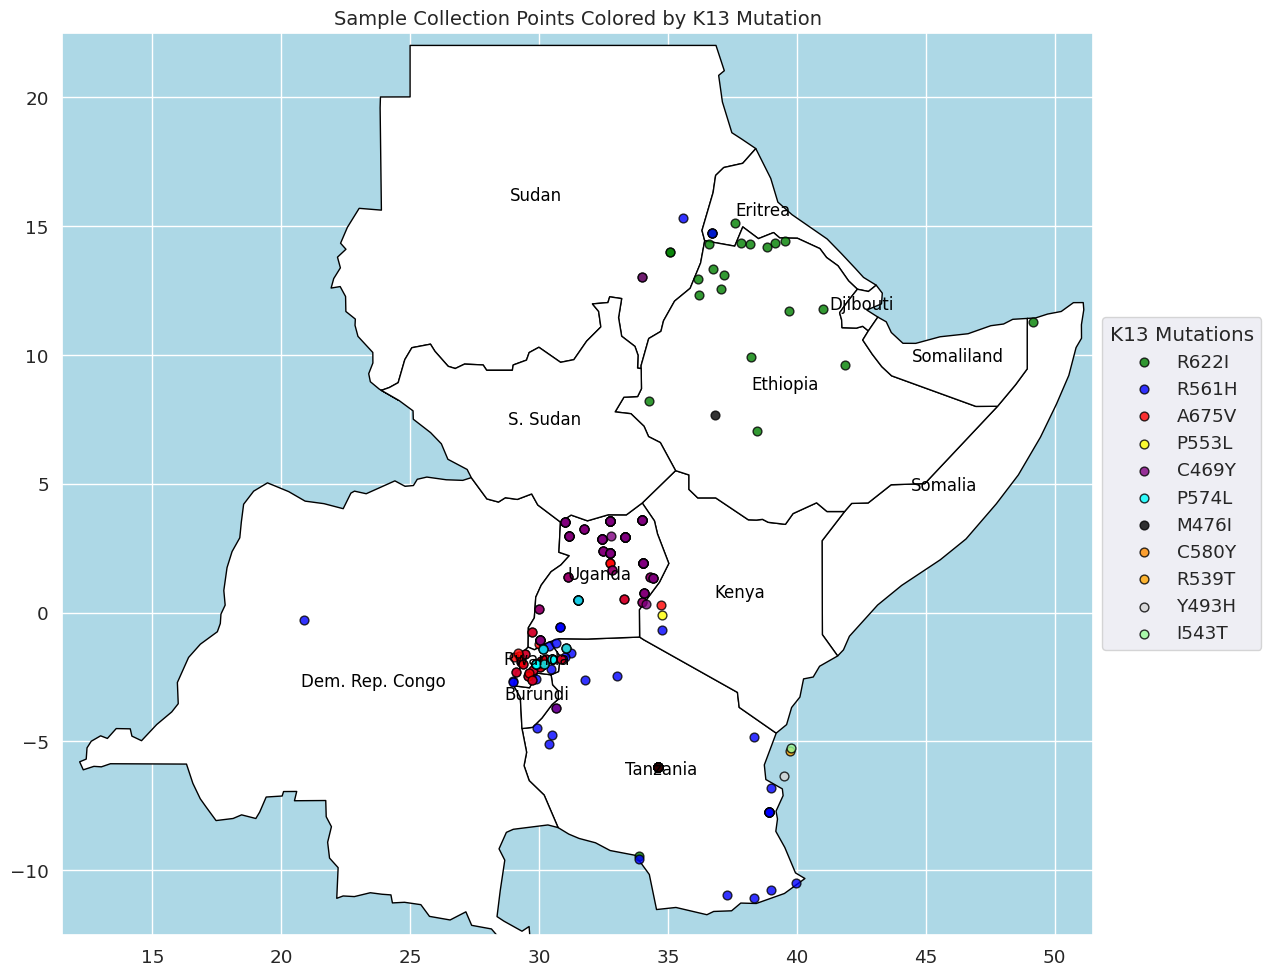

In [78]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# ----------------------------
# SETUP MUTATION COLORS
# ----------------------------
mutation_colors = {
    'R622I': 'green',
    'R561H': 'blue',
    'A675V': 'red',
    'P553L': 'yellow',
    'C469Y': 'purple',
    'P574L': 'cyan',
    'M476I': 'black',
    'C580Y': 'darkorange',
    'R539T': 'orange',
    'Y493H': 'lightgrey',
    'I543T': 'palegreen',
}
# ----------------------------
# CLEAN DATA
# ----------------------------
df = validated_df1.copy()
df['k13_validated_mutations'] = df['k13_validated_mutations'].str.strip().str.upper()
df = df[df['k13_validated_mutations'].isin(mutation_colors.keys())]
df = df.dropna(subset=['latitude', 'longitude','percentage_frequency'])

# ----------------------------
# LOAD MAP SHAPEFILE
# ----------------------------
world = gpd.read_file('../ne_110m_admin_0_map_units/ne_110m_admin_0_map_units.shp')

# ----------------------------
# FILTER TO AFRICAN COUNTRIES OF INTEREST
# ----------------------------
african_countries = [
    'Kenya', 'Uganda', 'Tanzania', 'Sudan', 'S. Sudan', 'Ethiopia', 'Rwanda', 'Dem. Rep. Congo',
    'Burundi', 'Djibouti', 'Eritrea', 'Somaliland', 'Somalia'
]

# Match country names (ensure correct column is used, e.g., 'NAME')
world_africa = world[world['NAME'].isin(african_countries)]

# ----------------------------
# PLOT MAP WITH SAMPLE POINTS
# ----------------------------
fig, ax = plt.subplots(figsize=(15, 10))
fig.patch.set_facecolor('white')  # Set figure background to white
ax.set_facecolor('lightblue') 
# Plot base map (filtered African countries)
world_africa.plot(ax=ax, color='white', edgecolor='black')

# Plot sample points by mutation
for mutation, color in mutation_colors.items():
    subset = df[df['k13_validated_mutations'] == mutation]
    ax.scatter(
        subset['longitude'], subset['latitude'],
        color=color, label=mutation, edgecolor='black', s=40, alpha=0.8
    )

# ----------------------------
# LABEL COUNTRIES
# ----------------------------
# Compute centroids for labeling
world_africa['centroid'] = world_africa.geometry.centroid

for _, row in world_africa.iterrows():
    ax.annotate(
        row['NAME'],
        xy=(row['centroid'].x, row['centroid'].y),
        ha='center', fontsize=12, color='black'
    )

# ----------------------------
# FINAL TOUCHES
# ----------------------------
ax.set_xlim(11.5, 51.5)
ax.set_ylim(-12.5, 22.5)
ax.set_aspect('equal', adjustable='box')
ax.legend(title='K13 Mutations', bbox_to_anchor=(1, 0.5), loc='center left')
ax.axis("on")


plt.title('Sample Collection Points Colored by K13 Mutation', fontsize=14)
plt.tight_layout()
plt.savefig("../results/sample_collection_points_labeled.png", dpi=300, bbox_inches='tight')
plt.show()

In [79]:
validated_df1[validated_df1["country"]=="Rwanda"]

,pmid,year_pub,year_sample,country,region/province,town,participants_age,participants_age_unit,sample_size,first_line_act,...,type_of_mutation,mutation_frequency_(%),where_sequenced,other_k13_mutations,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude
153,38746440,2024,2022-2023,Rwanda,Rwanda,Bugaragara,missing,missing,2709,AL,...,non-synonymous,49.1,Brown University,I205T,percentage,open,NaN,49.10,-1.29289,30.40766
155,38746440,2024,2022-2023,Rwanda,Rwanda,Busanza,missing,missing,2709,AL,...,non-synonymous,0.2,Brown University,A569V,percentage,open,NaN,0.20,-1.9285,29.3037
156,38746440,2024,2022-2023,Rwanda,Rwanda,Busanza,missing,missing,2709,AL,...,non-synonymous,28.4,Brown University,N133K,percentage,open,NaN,28.40,-1.9285,29.3037
163,38746440,2024,2022-2023,Rwanda,Rwanda,Byahi,missing,missing,2709,AL,...,non-synonymous,27.3,Brown University,K189T,percentage,open,NaN,27.30,-2.3086,29.1059
164,38746440,2024,2022-2023,Rwanda,Rwanda,Byahi,missing,missing,2709,AL,...,non-synonymous,2.7,Brown University,-,percentage,open,NaN,2.70,-2.3086,29.1059
165,38746440,2024,2022-2023,Rwanda,Rwanda,Gahanga,missing,missing,2709,AL,...,non-synonymous,2.2,Brown University,K189T,percentage,open,NaN,2.20,-2.024,30.10683
166,38746440,2024,2022-2023,Rwanda,Rwanda,Gahanga,missing,missing,2709,AL,...,non-synonymous,35.4,Brown University,N133K,percentage,open,NaN,35.40,-2.024,30.10683
168,38746440,2024,2022-2023,Rwanda,Rwanda,Gishubi,missing,missing,2709,AL,...,non-synonymous,1.1,Brown University,K189T,percentage,open,NaN,1.10,-2.5808,29.8764
170,38746440,2024,2022-2023,Rwanda,Rwanda,Giti,missing,missing,2709,AL,...,non-synonymous,41.7,Brown University,K189T,percentage,open,NaN,41.70,-2.66034,28.97556
171,38746440,2024,2022-2023,Rwanda,Rwanda,Giti,missing,missing,2709,AL,...,-,0,Brown University,A569V,none,open,NaN,NaN,-2.66034,28.97556


/tmp/ipykernel_25410/989415875.py:67: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world_africa['centroid'] = world_africa.geometry.centroid
/home/kimani/miniconda3/envs/PopStruct/lib/python3.13/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/tmp/ipykernel_25410/989415875.py:80: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  rwanda_centroid = rwanda_shape.geometry.centroid.iloc[0]
/tmp/ipykerne

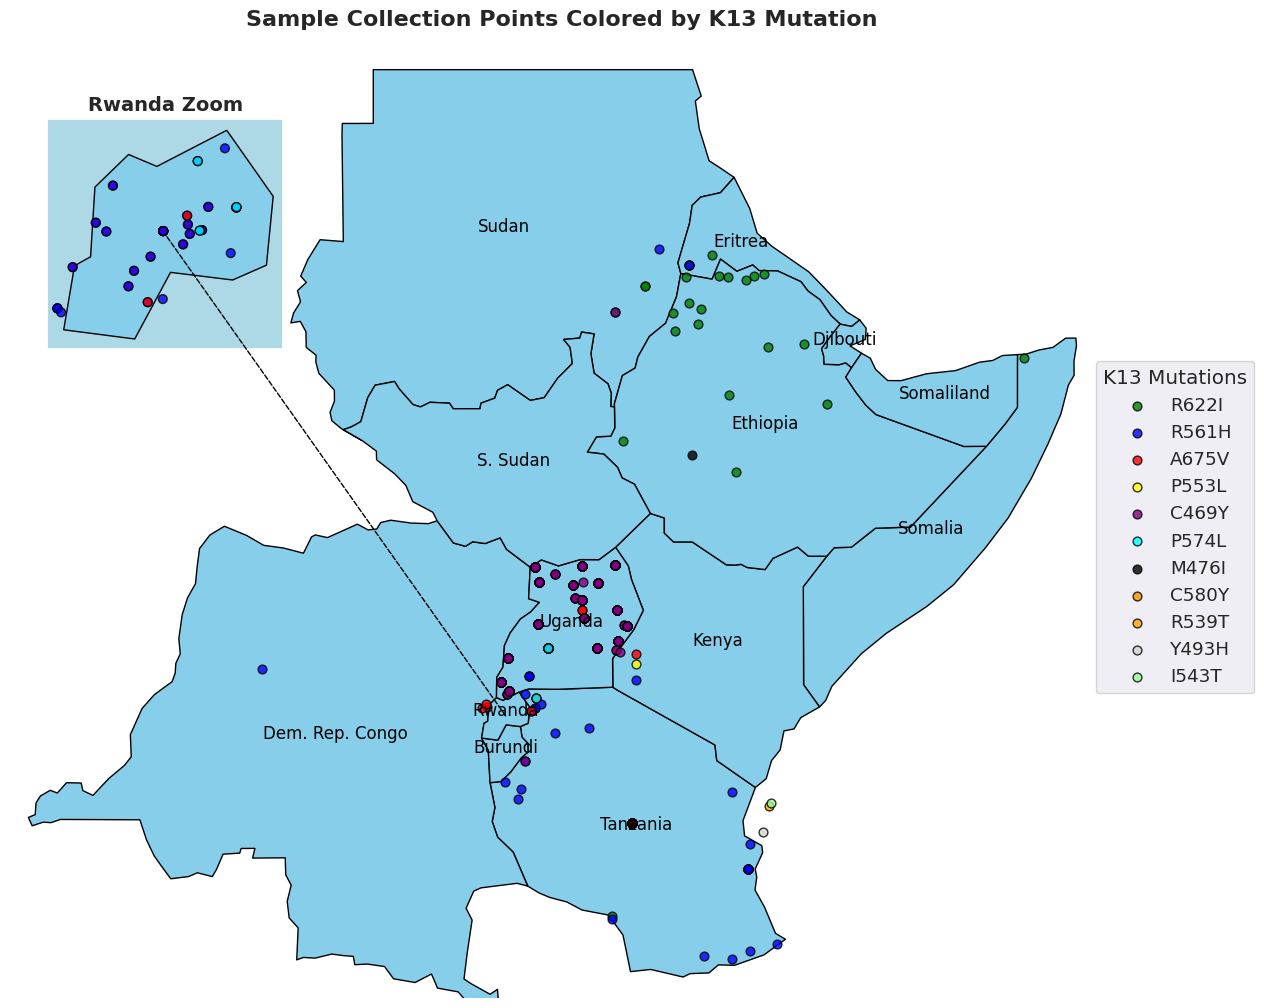

In [80]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ----------------------------
# SETUP MUTATION COLORS
# ----------------------------
mutation_colors = {
    'R622I': 'green',
    'R561H': 'blue',
    'A675V': 'red',
    'P553L': 'yellow',
    'C469Y': 'purple',
    'P574L': 'cyan',
    'M476I': 'black',
    'C580Y': 'darkorange',
    'R539T': 'orange',
    'Y493H': 'lightgrey',
    'I543T': 'palegreen',
}

# ----------------------------
# CLEAN DATA
# ----------------------------
df = validated_df1.copy()
df['k13_validated_mutations'] = df['k13_validated_mutations'].str.strip().str.upper()
df = df[df['k13_validated_mutations'].isin(mutation_colors.keys())]
df = df.dropna(subset=['latitude', 'longitude'])

# ----------------------------
# LOAD MAP SHAPEFILE
# ----------------------------
world = gpd.read_file('../ne_110m_admin_0_map_units/ne_110m_admin_0_map_units.shp')
#world=gpd.read_file("../ne_50m_admin_1_states_provinces/ne_50m_admin_1_states_provinces.shp")
# ----------------------------
# FILTER TO AFRICAN COUNTRIES OF INTEREST
# ----------------------------
african_countries = [
    'Kenya', 'Uganda', 'Tanzania', 'Sudan', 'S. Sudan', 'Ethiopia', 'Rwanda', 'Dem. Rep. Congo',
    'Burundi', 'Djibouti', 'Eritrea', 'Somaliland', 'Somalia'
]

world_africa = world[world['NAME'].isin(african_countries)]

# ----------------------------
# PLOT MAIN MAP
# ----------------------------
fig, ax = plt.subplots(figsize=(15, 10))
fig.patch.set_facecolor('white')
ax.set_facecolor('lightblue')

# Plot African countries
world_africa.plot(ax=ax, color='skyblue', edgecolor='black')

# Plot sample points by mutation (excluding Rwanda)
for mutation, color in mutation_colors.items():
    subset = df[(df['k13_validated_mutations'] == mutation) & (df['country'] != 'Rwanda')]
    ax.scatter(
        subset['longitude'], subset['latitude'],
        color=color, label=mutation, edgecolor='black', s=40, alpha=0.8
    )

# ----------------------------
# LABEL COUNTRIES ON MAIN MAP
# ----------------------------
world_africa['centroid'] = world_africa.geometry.centroid
for _, row in world_africa.iterrows():
    ax.annotate(
        row['NAME'],
        xy=(row['centroid'].x, row['centroid'].y),
        ha='center', fontsize=12, color='black'
    )

# ----------------------------
# INSET MAP FOR RWANDA
# ----------------------------
# Get Rwanda geometry
rwanda_shape = world_africa[world_africa['NAME'] == 'Rwanda']
rwanda_centroid = rwanda_shape.geometry.centroid.iloc[0]

# Create inset axes
ax_inset = inset_axes(ax, width="22%", height="30%", loc='upper left', borderpad=2)
ax_inset.set_facecolor('lightblue')

# Plot Rwanda only
rwanda_shape.plot(ax=ax_inset, color='skyblue', edgecolor='black')

# Plot mutation points in Rwanda
rwanda_points = df[df['country'] == 'Rwanda']
ax_inset.scatter(
    rwanda_points['longitude'], rwanda_points['latitude'],
    color=[mutation_colors[mut] for mut in rwanda_points['k13_validated_mutations']],
    edgecolor='black', s=40, alpha=0.8
)

ax_inset.set_title('Rwanda Zoom', fontsize=14, weight="bold")
ax_inset.set_xticks([])
ax_inset.set_yticks([])

# ----------------------------
# Add a line from main map to inset
# ----------------------------
# Connect from Rwanda centroid on main map to inset
con = ConnectionPatch(
    xyA=(rwanda_centroid.x, rwanda_centroid.y), coordsA=ax.transData,
    xyB=(0.5, 0.5), coordsB=ax_inset.transAxes,
    axesA=ax, axesB=ax_inset,
    color="black", linestyle="--", linewidth=1
)
fig.add_artist(con)


# ----------------------------
# FINAL TOUCHES
# ----------------------------
ax.set_xlim(11.5, 51.5)
ax.set_ylim(-12.5, 22.5)
ax.set_aspect('equal', adjustable='box')

# Legend
ax.legend(title='K13 Mutations', bbox_to_anchor=(1, 0.5), loc='center left')
ax.axis('off')
# Save & Show
plt.tight_layout(rect=[0, 0, 1, 0.985])  # Leaves just a bit of space for the title
plt.suptitle('Sample Collection Points Colored by K13 Mutation', fontsize=16, weight='bold', y=1.01)
plt.savefig("../results/sample_collection_points_labeled_rwanda1.png", dpi=300, bbox_inches='tight')
plt.show()


/tmp/ipykernel_25410/1729255318.py:67: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world_africa['centroid'] = world_africa.geometry.centroid
/home/kimani/miniconda3/envs/PopStruct/lib/python3.13/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/tmp/ipykernel_25410/1729255318.py:80: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  rwanda_centroid = rwanda_shape.geometry.centroid.iloc[0]
/tmp/ipyker

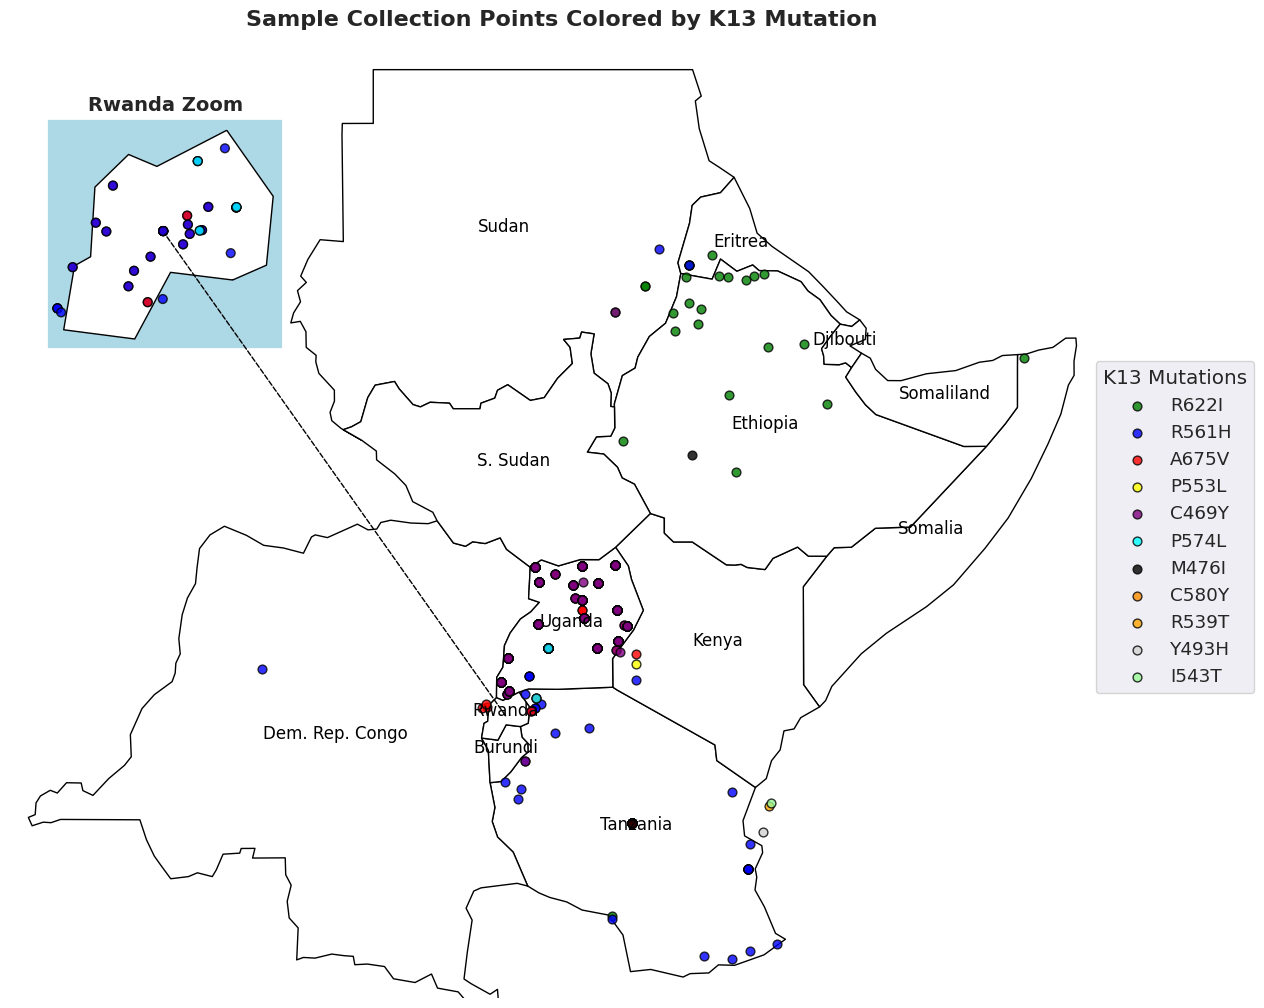

In [81]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ----------------------------
# SETUP MUTATION COLORS
# ----------------------------
mutation_colors = {
    'R622I': 'green',
    'R561H': 'blue',
    'A675V': 'red',
    'P553L': 'yellow',
    'C469Y': 'purple',
    'P574L': 'cyan',
    'M476I': 'black',
    'C580Y': 'darkorange',
    'R539T': 'orange',
    'Y493H': 'lightgrey',
    'I543T': 'palegreen',
}

# ----------------------------
# CLEAN DATA
# ----------------------------
df = validated_df1.copy()
df['k13_validated_mutations'] = df['k13_validated_mutations'].str.strip().str.upper()
df = df[df['k13_validated_mutations'].isin(mutation_colors.keys())]
df = df.dropna(subset=['latitude', 'longitude'])

# ----------------------------
# LOAD MAP SHAPEFILE
# ----------------------------
world = gpd.read_file('../ne_110m_admin_0_map_units/ne_110m_admin_0_map_units.shp')
#world=gpd.read_file("../ne_50m_admin_1_states_provinces/ne_50m_admin_1_states_provinces.shp")
# ----------------------------
# FILTER TO AFRICAN COUNTRIES OF INTEREST
# ----------------------------
african_countries = [
    'Kenya', 'Uganda', 'Tanzania', 'Sudan', 'S. Sudan', 'Ethiopia', 'Rwanda', 'Dem. Rep. Congo',
    'Burundi', 'Djibouti', 'Eritrea', 'Somaliland', 'Somalia'
]

world_africa = world[world['NAME'].isin(african_countries)]

# ----------------------------
# PLOT MAIN MAP
# ----------------------------
fig, ax = plt.subplots(figsize=(15, 10))
fig.patch.set_facecolor('white')
ax.set_facecolor('lightblue')

# Plot African countries
world_africa.plot(ax=ax, color='white', edgecolor='black')

# Plot sample points by mutation (excluding Rwanda)
for mutation, color in mutation_colors.items():
    subset = df[(df['k13_validated_mutations'] == mutation) & (df['country'] != 'Rwanda')]
    ax.scatter(
        subset['longitude'], subset['latitude'],
        color=color, label=mutation, edgecolor='black', s=40, alpha=0.8
    )

# ----------------------------
# LABEL COUNTRIES ON MAIN MAP
# ----------------------------
world_africa['centroid'] = world_africa.geometry.centroid
for _, row in world_africa.iterrows():
    ax.annotate(
        row['NAME'],
        xy=(row['centroid'].x, row['centroid'].y),
        ha='center', fontsize=12, color='black'
    )

# ----------------------------
# INSET MAP FOR RWANDA
# ----------------------------
# Get Rwanda geometry
rwanda_shape = world_africa[world_africa['NAME'] == 'Rwanda']
rwanda_centroid = rwanda_shape.geometry.centroid.iloc[0]

# Create inset axes
ax_inset = inset_axes(ax, width="22%", height="30%", loc='upper left', borderpad=2)
ax_inset.set_facecolor('lightblue')

# Plot Rwanda only
rwanda_shape.plot(ax=ax_inset, color='white', edgecolor='black')

# Plot mutation points in Rwanda
rwanda_points = df[df['country'] == 'Rwanda']
ax_inset.scatter(
    rwanda_points['longitude'], rwanda_points['latitude'],
    color=[mutation_colors[mut] for mut in rwanda_points['k13_validated_mutations']],
    edgecolor='black', s=40, alpha=0.8
)

ax_inset.set_title('Rwanda Zoom', fontsize=14, weight="bold")
ax_inset.set_xticks([])
ax_inset.set_yticks([])

# ----------------------------
# Add a line from main map to inset
# ----------------------------
# Connect from Rwanda centroid on main map to inset
con = ConnectionPatch(
    xyA=(rwanda_centroid.x, rwanda_centroid.y), coordsA=ax.transData,
    xyB=(0.5, 0.5), coordsB=ax_inset.transAxes,
    axesA=ax, axesB=ax_inset,
    color="black", linestyle="--", linewidth=1
)
fig.add_artist(con)


# ----------------------------
# FINAL TOUCHES
# ----------------------------
ax.set_xlim(11.5, 51.5)
ax.set_ylim(-12.5, 22.5)
ax.set_aspect('equal', adjustable='box')

# Legend
ax.legend(title='K13 Mutations', bbox_to_anchor=(1, 0.5), loc='center left')
ax.axis('off')
# Save & Show
plt.tight_layout(rect=[0, 0, 1, 0.985])  # Leaves just a bit of space for the title
plt.suptitle('Sample Collection Points Colored by K13 Mutation', fontsize=16, weight='bold', y=1.01)
plt.savefig("../results/sample_collection_points_labeled_rwanda_white.png", dpi=300, bbox_inches='tight')
plt.show()

In [82]:
world[world["NAME"]=="Zanzibar"]

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry


In [83]:
world1=gpd.read_file("../ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp")

In [84]:
world1[world1["NAME"]=="Zanzibar"]

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry


In [85]:
validated_df1[(validated_df1["country"]=="Kenya")&(validated_df1["k13_validated_mutations"]=="R622I")]

,pmid,year_pub,year_sample,country,region/province,town,participants_age,participants_age_unit,sample_size,first_line_act,...,type_of_mutation,mutation_frequency_(%),where_sequenced,other_k13_mutations,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude


In [86]:
validated_df2[validated_df2["year_sample"]=='2000-2007']

,pmid,year_pub,year_sample,country,region/province,town,samples_genotyped,k13_validated_mutations,type_of_mutation,mutation_frequency_(%),raw_count,percentage_frequency,latitude,longitude
903,10.2139/SSRN.4617870,2023,2000-2007,Kenya,missing,missing,54,R539T,non-synonymous,4.76,NaN,4.76,-,-
904,10.2139/SSRN.4617870,2023,2000-2007,Kenya,missing,missing,54,A675V,non-synonymous,7.14,NaN,7.14,-,-


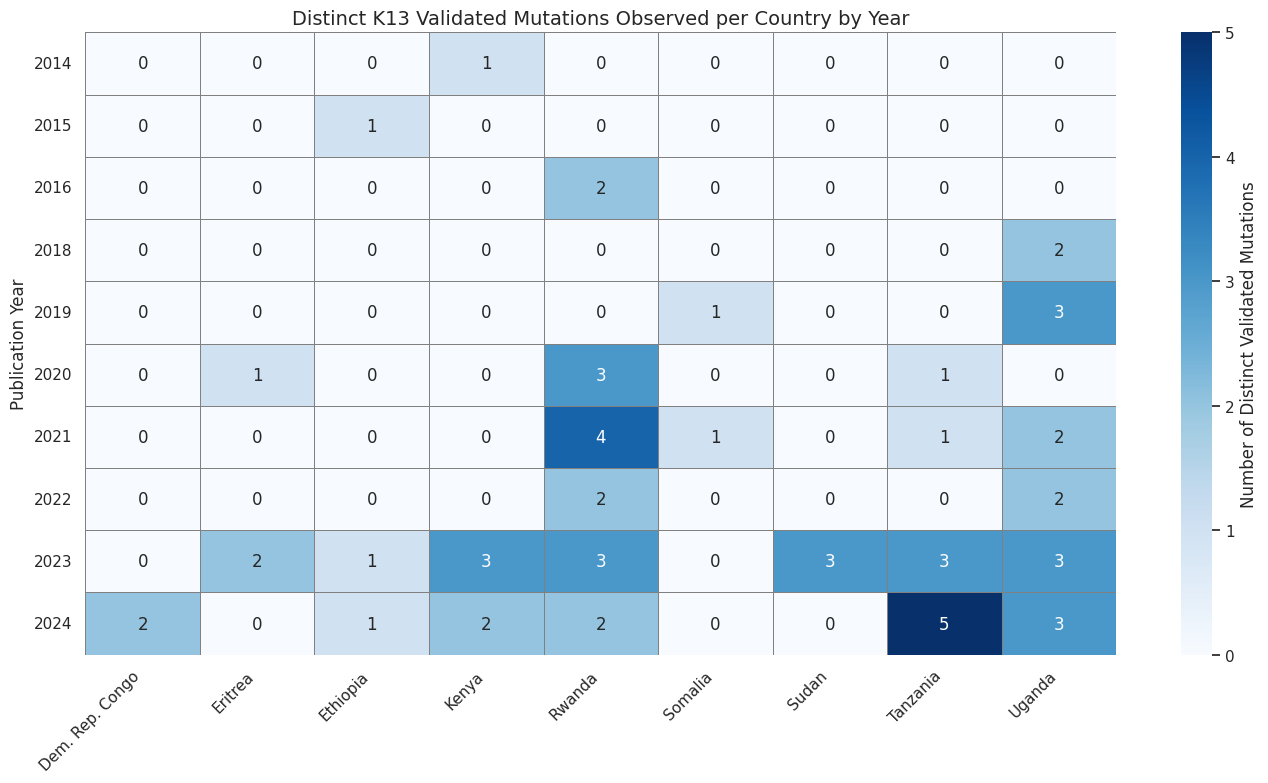

In [87]:
# Step 1: Filter rows with percentage_frequency > 0 and valid mutations
df_filtered = validated_df1[validated_df1['percentage_frequency'] > 0]

# Step 2: Drop duplicates (mutation, country, year) to avoid overcounting
df_unique = df_filtered.drop_duplicates(subset=['country', 'k13_validated_mutations', 'year_pub'])
df_unique = df_unique[df_unique["year_pub"] != 2028]

# Step 3: Group by year and country, count unique validated mutations
heatmap_data = (
    df_unique
    .groupby(['year_pub', 'country'])['k13_validated_mutations']
    .nunique()
    .unstack(fill_value=0)  # Rows = years, Columns = countries
)

# Step 4: Plot the heatmap
plt.figure(figsize=(14, 8))
sns.set(font_scale=1.0)

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={'label': 'Number of Distinct Validated Mutations'}
)

plt.title("Distinct K13 Validated Mutations Observed per Country by Year", fontsize=14)
plt.xlabel("")
plt.ylabel("Publication Year")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../distinct_validated_k13_country.png", dpi=300, bbox_inches='tight')
plt.show()


In [88]:
validated_df1[validated_df1["country"]=="Burundi"]["k13_validated_mutations"].unique()

array([], dtype=object)

In [89]:
validated_df1[(validated_df1["country"]=="Burundi") & (validated_df1["year_pub"]==2023)]['k13_validated_mutations']

Series([], Name: k13_validated_mutations, dtype: object)

# **Non Validated Mutations**

In [90]:
nonvalidated_df1=pd.read_excel("../K13_non_validated_v6.xlsx")

In [91]:
list=(nonvalidated_df1["other_k13_mutations"].unique())
list

array(['C532S', 'V661I', 'G595C', 'A578S', 'S695T', 'V555A', 'T685P',
       'L708I', 'Q613E', 'S522C', '-', 'H136N', 'L189T', 'T49S', 'L258M',
       'E433D', 'R255K', ' L258M', 'K189T', 'A175T', 'N133K', 'N137D',
       ' N137K', 'N217H', 'N264S', ' Q271L', ' E208K', 'G112E ', 'H384R',
       ' I205T', 'L116I', 'K189N', 'F699C', 'P419S', 'P667S', 'S182T',
       'T149S', 'T207K', 'T348I', 'K108E', ' H136N', 'N137K', ' N264S',
       'Q271L', 'G112E', ' L177I', 'L99V', ' K108E', 'K124N', ' K189T',
       ' K9R', 'P667T', ' N217H', ' L116I', ' L99V', 'P96Q', 'A569S',
       'F491S ', 'V520A', 'A557S', 'V581V', 'A617T', 'V637A', 'R471R ',
       'G496G', 'R513R', 'V589V', 'C469C', 'S477Y', 'I416V', 'R471S',
       'A621V', 'K610E', 'P615N', 'N594K', 'L618S', 'W470R', 'V581I',
       'K563E', 'I540T', 'G533A\xa0', 'G496S', 'E567K', 'A578S\xa0',
       'L457I', 'W565R', 'I465T', 'C469F', 'M472V', 'Y558H', 'A569T',
       'Y588N', 'I587I', 'E596V', 'E643K', 'S600C', 'P553P', 'S477S',
     

In [92]:
nonvalidated_df1["other_k13_mutations"] = nonvalidated_df1["other_k13_mutations"].str.strip()

In [93]:
# Fix country name mismatches manually (example)
country_name_map = {
     'DRC' : "Dem. Rep. Congo",
    "South Sudan" : 'S. Sudan'
}

# Standardize names
nonvalidated_df1['country'] = nonvalidated_df1['country'].replace(country_name_map)


In [94]:
nonvalidated_df1["year_pub"].unique()

array([2021, 2022, 2024, 2015, 2018, 2014, 2019, 2020, 2016, 2023, 2028,
       2017])

In [95]:
year= {
    2028:2023
}

#standardize names
nonvalidated_df1["year_pub"]= nonvalidated_df1["year_pub"].replace(year)

In [96]:
nonvalidated_df1["year_pub"].unique()

array([2021, 2022, 2024, 2015, 2018, 2014, 2019, 2020, 2016, 2023, 2017])

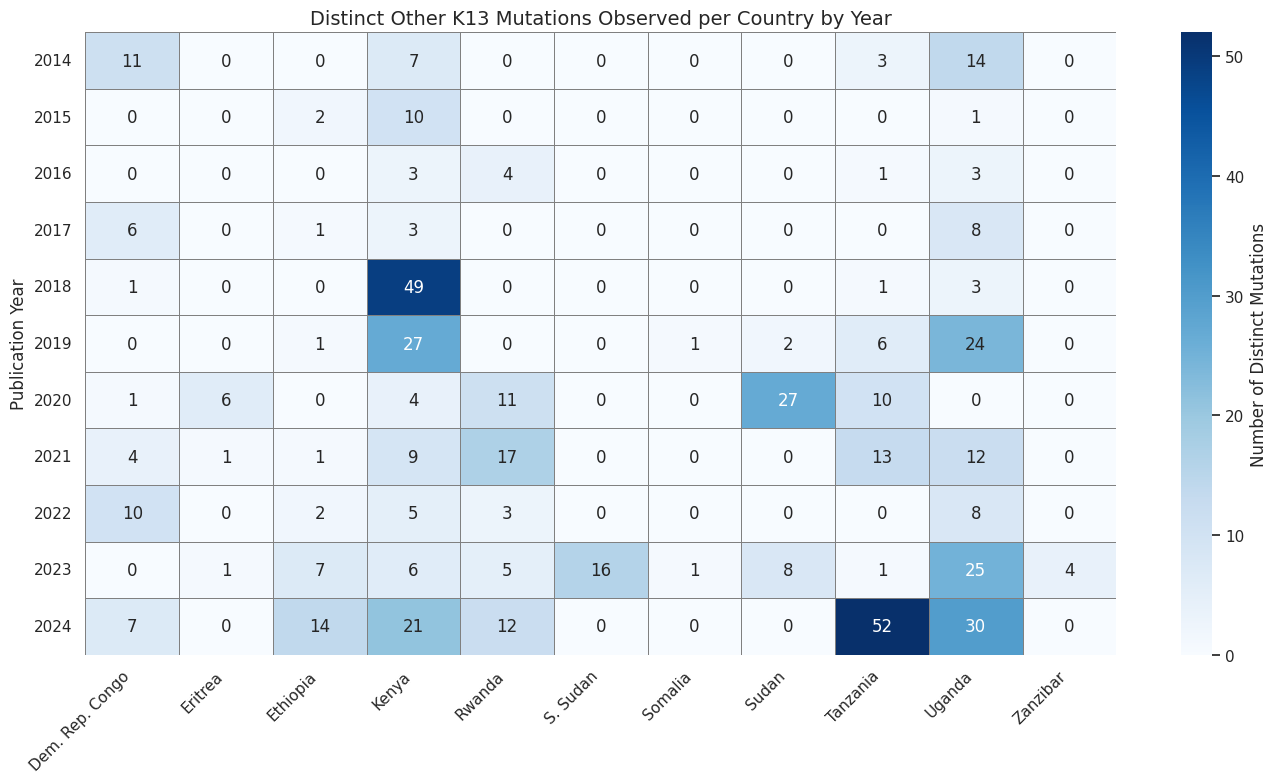

In [97]:

# Step 1: Filter rows with percentage_frequency > 0 and remove a specific PMID
df_filtered = nonvalidated_df1.copy()

# Step 2: Drop duplicates (mutation, country, year) to avoid overcounting
df_unique = df_filtered.drop_duplicates(subset=['country', 'other_k13_mutations', 'year_pub'])
# Step 3: Group by year and country, count unique other_k13_mutations
heatmap_data = (
    df_unique
    .groupby(['year_pub', 'country'])['other_k13_mutations']
    .nunique()
    .unstack(fill_value=0)  # Rows = years, Columns = countries
)

# Step 4: Plot the heatmap
plt.figure(figsize=(14, 8))
sns.set(font_scale=1.0)

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="gray",
    #cbar=False,
    cbar_kws={'label': 'Number of Distinct Mutations'}
)

plt.title("Distinct Other K13 Mutations Observed per Country by Year", fontsize=14)
plt.xlabel("")
plt.ylabel("Publication Year")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../distinct_other_k13_country.png", dpi=300, bbox_inches='tight')
plt.show()


In [98]:
nonvalidated_df1[(nonvalidated_df1["country"]=="Kenya") & (nonvalidated_df1["year_pub"]==2018)]["other_k13_mutations"].unique()

array(['S485K', 'N498I', 'L505F', 'W518C', 'R529K', 'N530K', 'V568G',
       'A578S', 'N587K', 'A676V', 'T677K', 'T677R', 'T677S', 'L678V',
       'A504G', 'E509G', 'N530Y', 'G592E', 'E596R', 'D584Y', 'N585K',
       'N609L', 'Y616N', 'E620K', 'R622G', 'S522R', 'N530I', 'N531I',
       'S536L', 'R539K', 'P570L', 'L598F', 'T677A', 'T474T', 'A569S', '-',
       'C469W', 'C469C', 'R513S', 'R597R', 'N490S', 'E507E', 'L457I',
       'G548G', 'I448M', 'S522C', 'A554S', 'I590F', 'E612D'], dtype=object)

In [99]:
df_unique[(df_unique["country"]=="Kenya") &(df_unique["year_pub"]==2014)]

,pmid,year_pub,year_sample,country,region/province,town,participants_age,participants_age_unit,sample_size,first_line_act,...,samples_genotyped,where_sequenced,other_k13_mutations,Frequency,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude
141,25180240,2014,2009-2012,Kenya,Western Kenya,Siaya,missing,missing,53,AL,...,53,missing,V520A,1.93,percentage,open,NaN,1.93,0.06116,34.28823
154,25180240,2014,2002-2004,Kenya,Western Kenya,Kisumu,missing,missing,50,AL,...,50,missing,C469C,1.24,percentage,open,NaN,1.24,-0.10221,34.76171
1396,25367300,2014,2013-2014,Kenya,-,Kisumu,≥0.5,months,108,missing,...,108,Wellcome Trust Sanger Institute,T478T,1(0.93),raw counts,open,1.0,0.93,-0.069,34.64
1397,25367300,2014,2013-2014,Kenya,-,Kisumu,≥0.5,months,108,missing,...,108,Wellcome Trust Sanger Institute,E509E,1(0.93),raw counts,open,1.0,0.93,-0.069,34.64
1398,25367300,2014,2013-2014,Kenya,-,Kisumu,≥0.5,months,108,missing,...,108,Wellcome Trust Sanger Institute,A569T,1(0.93),raw counts,open,1.0,0.93,-0.069,34.64
1399,25367300,2014,2013-2014,Kenya,-,Kisumu,≥0.5,months,108,missing,...,108,Wellcome Trust Sanger Institute,A578S,3(2.78),raw counts,open,3.0,2.78,-0.069,34.64
1400,25367300,2014,2013-2014,Kenya,-,Kisumu,≥0.5,months,108,missing,...,108,Wellcome Trust Sanger Institute,Y630F,1(0.93),raw counts,open,1.0,0.93,-0.069,34.64


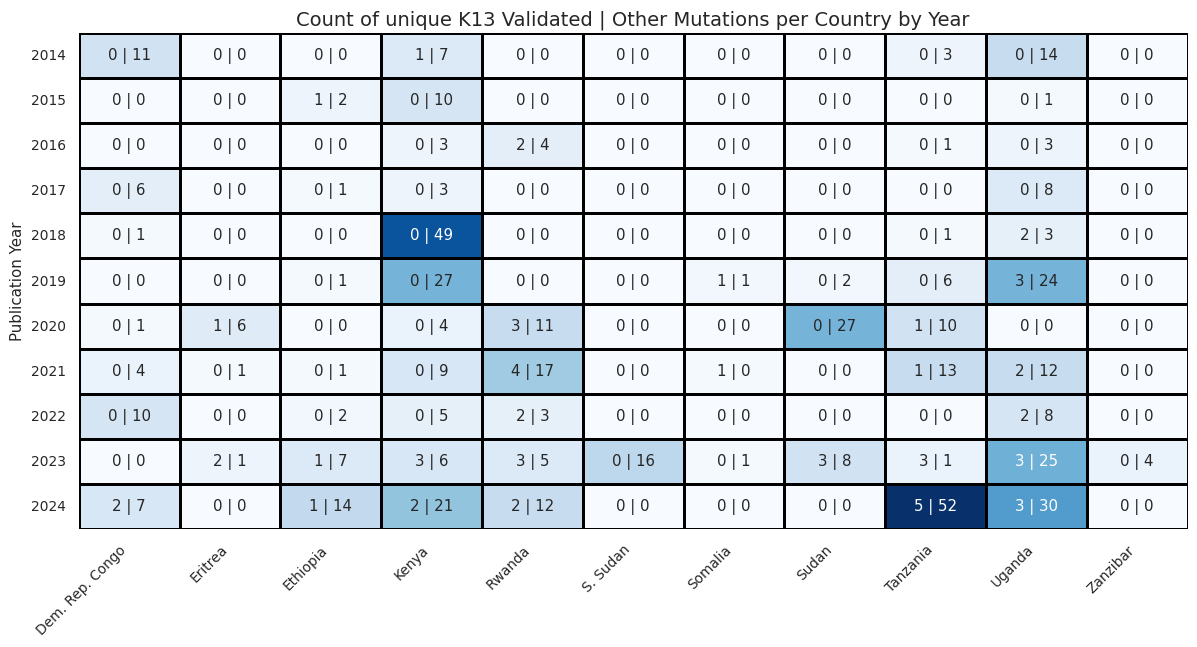

In [100]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------
# Step 1: Preprocess validated data
# ----------------------------
val_df = validated_df1.copy()
val_df = val_df[val_df['percentage_frequency'] > 0]
val_df = val_df.drop_duplicates(subset=['country', 'k13_validated_mutations', 'year_pub'])

validated_counts = (
    val_df.groupby(['year_pub', 'country'])['k13_validated_mutations']
    .nunique()
    .unstack(fill_value=0)
)

# ----------------------------
# Step 2: Preprocess non-validated data
# ----------------------------
nonval_df = nonvalidated_df1.copy()
#nonval_df = nonval_df[nonval_df['percentage_frequency'] > 0]
nonval_df = nonval_df.drop_duplicates(subset=['country', 'other_k13_mutations', 'year_pub'])

nonvalidated_counts = (
    nonval_df.groupby(['year_pub', 'country'])['other_k13_mutations']
    .nunique()
    .unstack(fill_value=0)
)

# ----------------------------
# Step 3: Align both tables and fill missing values
# ----------------------------
all_years = sorted(set(validated_counts.index) | set(nonvalidated_counts.index))
all_countries = sorted(set(validated_counts.columns) | set(nonvalidated_counts.columns))

validated_counts = validated_counts.reindex(index=all_years, columns=all_countries, fill_value=0)
nonvalidated_counts = nonvalidated_counts.reindex(index=all_years, columns=all_countries, fill_value=0)

# ----------------------------
# Step 4: Combine into single table as string
# ----------------------------
combined_table = validated_counts.astype(str) + " | " + nonvalidated_counts.astype(str)

# ----------------------------
# Step 5: Plot heatmap-like annotated table
# ----------------------------
plt.figure(figsize=(len(all_countries) * 1.1, len(all_years) * 0.6))
sns.set(font_scale=0.9)

ax = sns.heatmap(
    validated_counts + nonvalidated_counts,  # used only to generate color (can also be just 0s)
    annot=combined_table,
    fmt="",
    cmap="Blues",
    linewidths=0.73,
    linecolor="black",
    cbar=False  # Hide colorbar
)

plt.title("Count of unique K13 Validated | Other Mutations per Country by Year", fontsize=14)
plt.xlabel("")
plt.ylabel("Publication Year")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../results/k13_validated_vs_other_table.png", dpi=300, bbox_inches='tight')
plt.show()

In [101]:
validated_df1[(validated_df1["country"]=="Tanzania")&(validated_df1["year_pub"]==2024) & (validated_df1['k13_validated_mutations']=="C469Y")]

,pmid,year_pub,year_sample,country,region/province,town,participants_age,participants_age_unit,sample_size,first_line_act,...,type_of_mutation,mutation_frequency_(%),where_sequenced,other_k13_mutations,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude
227,38746440,2024,2022-2023,Tanzania,Tanzania,Kibingo,missing,missing,1692,AL,...,non-synonymous,0.7,Brown University,I205T,none,open,NaN,0.7,-3.69906,30.65566


In [102]:
nonvalidated_df1[(nonvalidated_df1["country"]=="Rwanda")&(nonvalidated_df1["year_pub"]==2021)]["other_k13_mutations"].unique()

array(['C469F', 'G533A', 'V555A', 'A578S', 'M460I', 'V487I', 'A578V',
       'A626E', 'G592E+V637I', 'R513L', 'R575I', 'E605K', 'E651K',
       'P667R', 'P441L', 'G449A', 'R575K'], dtype=object)

In [103]:
validated_df1["country"].unique()

array(['Uganda', 'Ethiopia', 'Dem. Rep. Congo', 'Tanzania', 'Kenya',
       'Rwanda', 'Zanzibar', 'Somalia', 'Eritrea', 'South Sudan', 'Sudan'],
      dtype=object)

In [104]:
df_unique[(df_unique["country"]=="Rwanda")&(df_unique["year_pub"]==2021)]["other_k13_mutations"].unique()

array(['C469F', 'G533A', 'V555A', 'A578S', 'M460I', 'V487I', 'A578V',
       'A626E', 'G592E+V637I', 'R513L', 'R575I', 'E605K', 'E651K',
       'P667R', 'P441L', 'G449A', 'R575K'], dtype=object)

In [105]:
df_filtered[df_filtered["country"]=="Kenya"]["other_k13_mutations"].unique()

array(['-', 'A578S', 'R255K', 'S182T', 'P96Q', 'V520A', 'C469C', 'S522C',
       'A569S', 'P553P', 'S477S', 'M442V', 'Y500Y', 'G538G', 'N554S',
       'C439C', 'N531N', 'V568I', 'I416V', 'H384Y', 'Y328F', 'L258M',
       'K189T', 'G533G', 'P655P', 'G690G', 'A582V', 'T535T', 'I646L',
       'V637V', 'H560H', 'E643E', 'P667S', 'F451Y', 'R539T', 'N458Y',
       'N431S', 'A671V', '"504, 510"', 'W611S', 'C469T', 'S485K', 'N498I',
       'L505F', 'W518C', 'R529K', 'N530K', 'V568G', 'N587K', 'A676V',
       'T677K', 'T677R', 'T677S', 'L678V', 'A504G', 'E509G', 'N530Y',
       'G592E', 'E596R', 'D584Y', 'N585K', 'N609L', 'Y616N', 'E620K',
       'R622G', 'S522R', 'N530I', 'N531I', 'S536L', 'R539K', 'P570L',
       'L598F', 'T677A', 'T474T', 'C469W', 'R513S', 'R597R', 'N490S',
       'E507E', 'L457I', 'G548G', 'I448M', 'A554S', 'I590F', 'E612D',
       'D399N', 'A486S', 'C542R', 'G665S',
       'I354V, A486S, V487A, S522C, A578S, A582V, S600A, I634L, V666L, A676S',
       'S549P', 'S38C', 'K108

In [106]:
validated_df1["country"].unique()

array(['Uganda', 'Ethiopia', 'Dem. Rep. Congo', 'Tanzania', 'Kenya',
       'Rwanda', 'Zanzibar', 'Somalia', 'Eritrea', 'South Sudan', 'Sudan'],
      dtype=object)

In [107]:
validated_df1[validated_df1["country"]=="Somalia"]

,pmid,year_pub,year_sample,country,region/province,town,participants_age,participants_age_unit,sample_size,first_line_act,...,type_of_mutation,mutation_frequency_(%),where_sequenced,other_k13_mutations,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude
911,34279219,2021,2016-2017,Somalia,missing,missing,missing,missing,138,AL,...,non-synonymous,1/138,"Institut Pasteur, Paris",-,raw counts,open,1.0,0.72,None,None
945,31296223,2019,2016-2017,Somalia,"Middle Shabelle, Puntland","Jowhar, Bosaso",>0.5,years,339,"AL,DHA/PPQ",...,non-synonymous,1/139(0.7),Institut Pasteur (Cambodia),-,raw counts,open,1.0,0.70,11.28421,49.18158


In [108]:
# Fix country name mismatches manually (example)
ch1= {
     '-' : None
}

# Standardize names
nonvalidated_df1['longitude'] = nonvalidated_df1['longitude'].replace(ch)
nonvalidated_df1['latitude'] = nonvalidated_df1['latitude'].replace(ch)

/tmp/ipykernel_25410/1268145553.py:74: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world_filtered['centroid'] = world_filtered.geometry.centroid


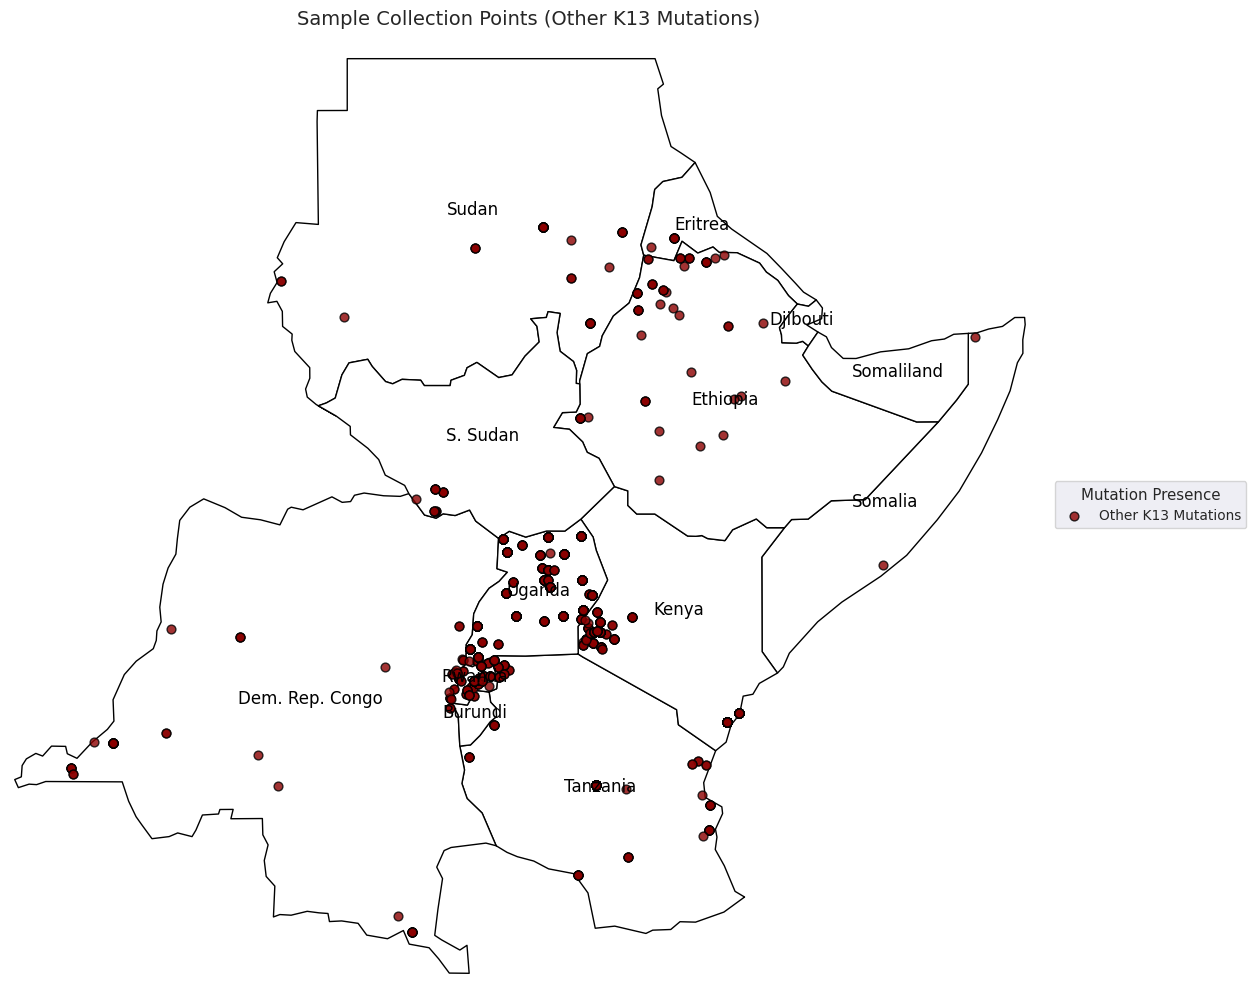

In [109]:
# ----------------------------
# SETUP: Define a single color for all mutations
# ----------------------------
mutation_color = 'darkred'  # Pick any color you prefer

# ----------------------------
# CUSTOM LIST OF AFRICAN COUNTRIES (DO NOT CHANGE)
# ----------------------------
african_countries = [
    'Kenya', 'Uganda', 'Tanzania', 'Sudan', 'S. Sudan', 'Ethiopia', 'Rwanda', 'Dem. Rep. Congo',
    'Burundi', 'Djibouti', 'Eritrea', 'Somaliland', 'Somalia', "Zanzibar"
]

# ----------------------------
# CLEAN DATA
# ----------------------------
df = nonvalidated_df1.copy()
df['other_k13_mutations'] = df['other_k13_mutations'].str.strip().str.upper()
df = df.dropna(subset=['latitude', 'longitude'])

# ----------------------------
# LOAD MAP SHAPEFILE
# ----------------------------
world = gpd.read_file('../ne_110m_admin_0_map_units/ne_110m_admin_0_map_units.shp')

# ----------------------------
# FILTER TO SPECIFIC COUNTRIES ONLY
# ----------------------------
world_filtered = world[world['NAME'].isin(african_countries)]

# ----------------------------
# CREATE POINTS GEO-DATAFRAME
# ----------------------------
points_gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
    crs='EPSG:4326'
)

# ----------------------------
# SPATIAL JOIN: Keep only points inside selected countries
# ----------------------------
# Project both to Web Mercator
world_proj = world_filtered.to_crs(epsg=3857)
points_proj = points_gdf.to_crs(epsg=3857)

# Spatial join to keep points within selected African countries
points_proj = gpd.sjoin(points_proj, world_proj, how='inner', predicate='within')

# Reproject back for plotting
world_filtered = world_proj.to_crs(epsg=4326)
points_gdf = points_proj.to_crs(epsg=4326)

# ----------------------------
# PLOT MAP
# ----------------------------
fig, ax = plt.subplots(figsize=(15, 10))
fig.patch.set_facecolor('white')  # Set figure background to white
ax.set_facecolor('lightblue')     # Ocean color

# Plot filtered countries
world_filtered.plot(ax=ax, color='white', edgecolor='black')

# Plot sample points
ax.scatter(
    points_gdf['longitude'], points_gdf['latitude'],
    color=mutation_color, label='Other K13 Mutations',
    edgecolor='black', s=40, alpha=0.8
)

# ----------------------------
# LABEL ONLY COUNTRIES IN THE LIST
# ----------------------------
world_filtered['centroid'] = world_filtered.geometry.centroid
for _, row in world_filtered.iterrows():
    centroid = row['centroid']
    ax.annotate(
        row['NAME'],
        xy=(centroid.x, centroid.y),
        ha='center', fontsize=12, color='black'
    )

# ----------------------------
# FINAL TOUCHES
# ----------------------------
ax.set_xlim(12, 52)
ax.set_ylim(-13.4, 23)
ax.set_aspect('equal', adjustable='box')
ax.axis("off")
ax.legend(title='Mutation Presence', bbox_to_anchor=(1, 0.5), loc='center left')
plt.title('Sample Collection Points (Other K13 Mutations)', fontsize=14)
plt.tight_layout()
plt.savefig("../results/other_k13_mutations_points_filtered_white.png", dpi=300, bbox_inches='tight')
plt.show()


/tmp/ipykernel_25410/4109409211.py:74: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world_filtered['centroid'] = world_filtered.geometry.centroid


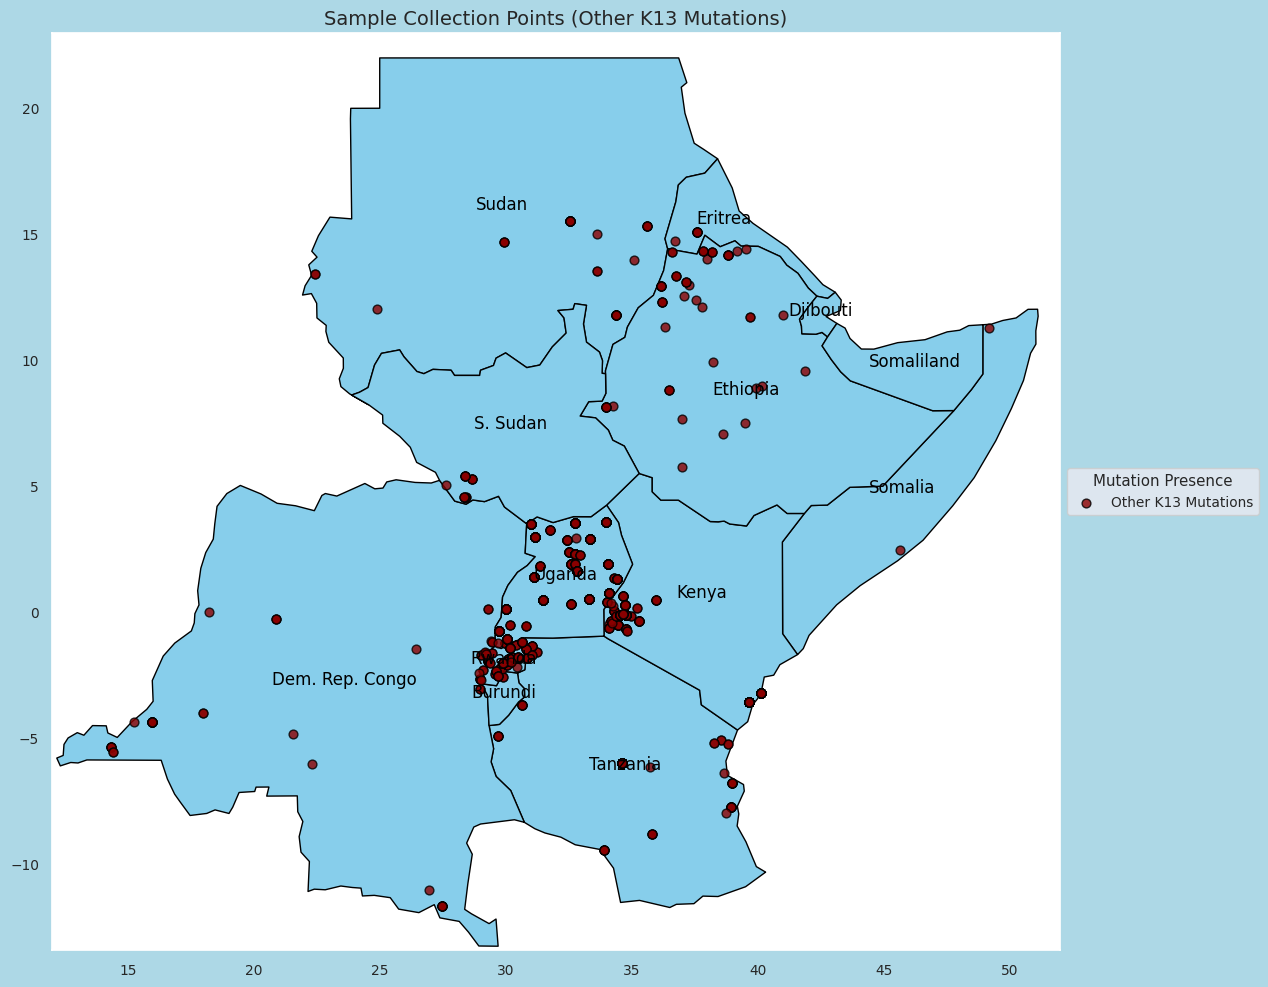

In [110]:
# ----------------------------
# SETUP: Define a single color for all mutations
# ----------------------------
mutation_color = 'darkred'  # Pick any color you prefer

# ----------------------------
# CUSTOM LIST OF AFRICAN COUNTRIES (DO NOT CHANGE)
# ----------------------------
african_countries = [
    'Kenya', 'Uganda', 'Tanzania', 'Sudan', 'S. Sudan', 'Ethiopia', 'Rwanda', 'Dem. Rep. Congo',
    'Burundi', 'Djibouti', 'Eritrea', 'Somaliland', 'Somalia', "Zanzibar"
]

# ----------------------------
# CLEAN DATA
# ----------------------------
df = nonvalidated_df1.copy()
df['other_k13_mutations'] = df['other_k13_mutations'].str.strip().str.upper()
df = df.dropna(subset=['latitude', 'longitude'])

# ----------------------------
# LOAD MAP SHAPEFILE
# ----------------------------
world = gpd.read_file('../ne_110m_admin_0_map_units/ne_110m_admin_0_map_units.shp')

# ----------------------------
# FILTER TO SPECIFIC COUNTRIES ONLY
# ----------------------------
world_filtered = world[world['NAME'].isin(african_countries)]

# ----------------------------
# CREATE POINTS GEO-DATAFRAME
# ----------------------------
points_gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
    crs='EPSG:4326'
)

# ----------------------------
# SPATIAL JOIN: Keep only points inside selected countries
# ----------------------------
# Project both to Web Mercator
world_proj = world_filtered.to_crs(epsg=3857)
points_proj = points_gdf.to_crs(epsg=3857)

# Spatial join to keep points within selected African countries
points_proj = gpd.sjoin(points_proj, world_proj, how='inner', predicate='within')

# Reproject back for plotting
world_filtered = world_proj.to_crs(epsg=4326)
points_gdf = points_proj.to_crs(epsg=4326)

# ----------------------------
# PLOT MAP
# ----------------------------
fig, ax = plt.subplots(figsize=(15, 10))
fig.patch.set_facecolor('lightblue')  # Set figure background to white
ax.set_facecolor('white')     # Ocean color

# Plot filtered countries
world_filtered.plot(ax=ax, color='skyblue', edgecolor='black')

# Plot sample points
ax.scatter(
    points_gdf['longitude'], points_gdf['latitude'],
    color=mutation_color, label='Other K13 Mutations',
    edgecolor='black', s=40, alpha=0.8
)

# ----------------------------
# LABEL ONLY COUNTRIES IN THE LIST
# ----------------------------
world_filtered['centroid'] = world_filtered.geometry.centroid
for _, row in world_filtered.iterrows():
    centroid = row['centroid']
    ax.annotate(
        row['NAME'],
        xy=(centroid.x, centroid.y),
        ha='center', fontsize=12, color='black'
    )

# ----------------------------
# FINAL TOUCHES
# ----------------------------
ax.set_xlim(12, 52)
ax.set_ylim(-13.4, 23)
ax.set_aspect('equal', adjustable='box')
ax.axis("on")
ax.legend(title='Mutation Presence', bbox_to_anchor=(1, 0.5), loc='center left')
plt.title('Sample Collection Points (Other K13 Mutations)', fontsize=14)
plt.tight_layout()
plt.savefig("../results/other_k13_mutations_points_filtered_box.png", dpi=300, bbox_inches='tight')
plt.show()


In [111]:
unvaldf=(
    df.groupby(['country', 'other_k13_mutations'])['percentage_frequency']
    .mean()
    .reset_index()
)
unvaldf

,country,other_k13_mutations,percentage_frequency
0,Dem. Rep. Congo,-,NaN
1,Dem. Rep. Congo,A557S,36.310000
2,Dem. Rep. Congo,A578S,0.803333
3,Dem. Rep. Congo,A617T,1.750000
4,Dem. Rep. Congo,C532S,NaN
...,...,...,...
420,Uganda,Y630F,1.250000
421,Zanzibar,A481V,NaN
422,Zanzibar,G538V,NaN
423,Zanzibar,N573I,NaN


In [112]:
df["country"].unique()

array(['Uganda', 'Dem. Rep. Congo', 'Kenya', 'Ethiopia', 'Tanzania',
       'Sudan', 'Rwanda', 'Eritrea', 'Zanzibar', 'Somalia', 'S. Sudan'],
      dtype=object)

In [113]:
df[df["country"]=="South Sudan"]["latitude"].nunique()

0

In [114]:
unvaldf[unvaldf["country"]=="Zanzibar"]

,country,other_k13_mutations,percentage_frequency
421,Zanzibar,A481V,NaN
422,Zanzibar,G538V,NaN
423,Zanzibar,N573I,NaN
424,Zanzibar,P527H,NaN


In [115]:
nonvalidated_df1[nonvalidated_df1["country"]=="DRC"]["pmid"].unique()

array([], dtype=object)

/tmp/ipykernel_25410/2577801452.py:123: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world_filtered['centroid'] = world_filtered.geometry.centroid


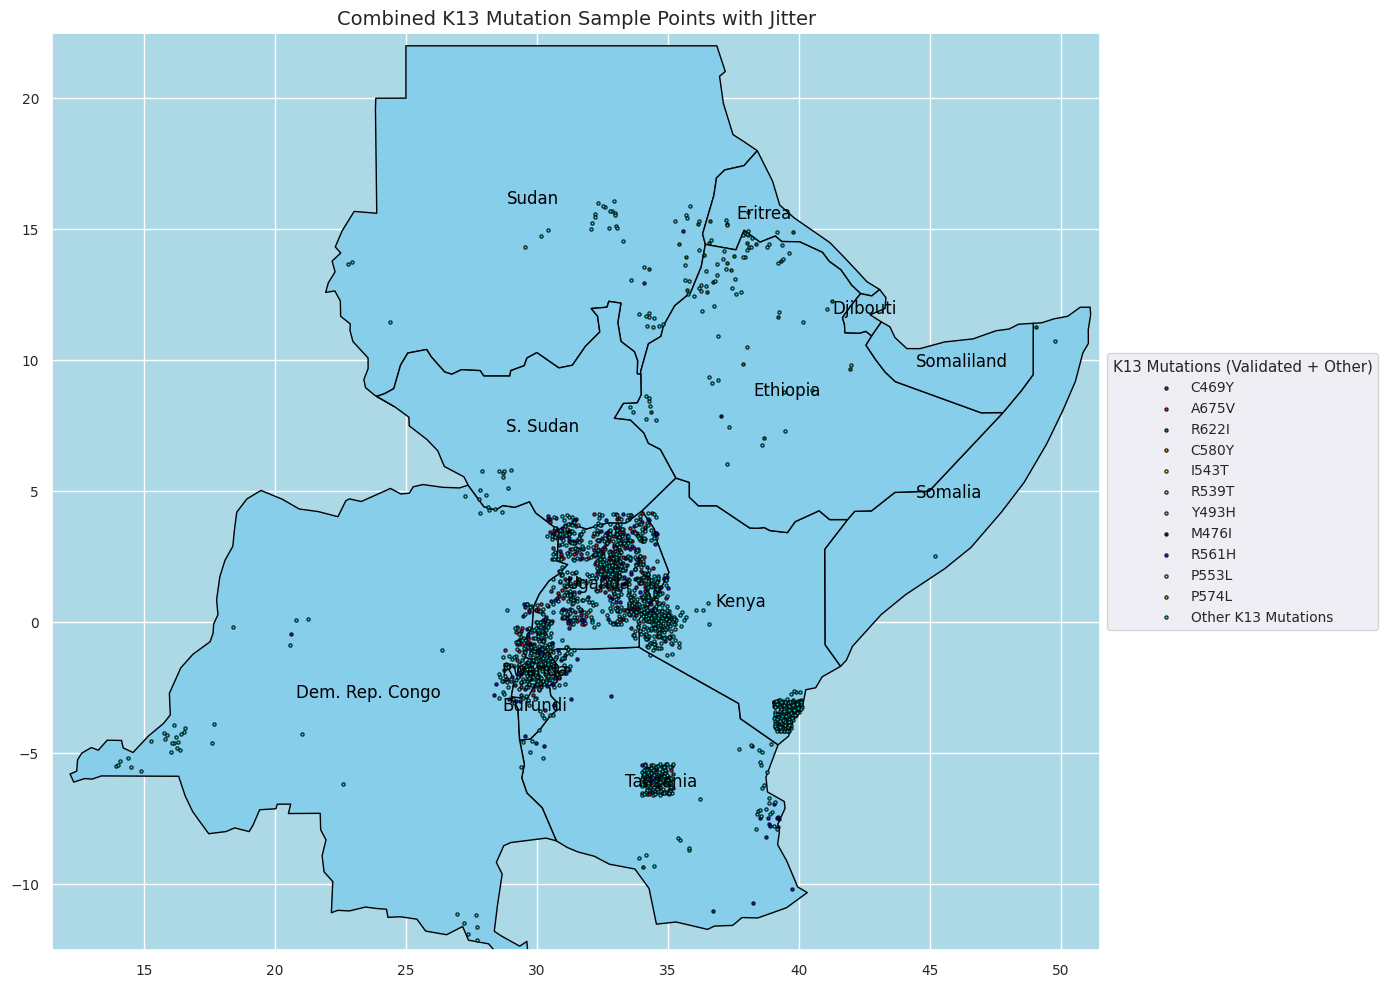

In [116]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# SETUP MUTATION COLORS
# ----------------------------
validated_colors = {
    'C469Y': 'purple',
    'A675V': 'red',
    'R622I': 'green',
    'C580Y': 'darkorange',
    'I543T': 'yellow',
    'R539T': 'palegreen',
    'Y493H': 'lightgrey',
    'M476I': 'black',
    'R561H': 'blue',
    'P553L': 'pink',
    'P574L': 'orange',
}
nonvalidated_color = 'cyan'

# ----------------------------
# CUSTOM LIST OF AFRICAN COUNTRIES (DO NOT CHANGE)
# ----------------------------
african_countries = [
    'Kenya', 'Uganda', 'Tanzania', 'Sudan', 'S. Sudan', 'Ethiopia', 'Rwanda', 'Dem. Rep. Congo',
    'Burundi', 'Djibouti', 'Eritrea', 'Somaliland', 'Somalia'
]

# ----------------------------
# CLEAN VALIDATED DATA
# ----------------------------
validated_df = validated_df1.copy()
validated_df['k13_validated_mutations'] = validated_df['k13_validated_mutations'].str.strip().str.upper()
validated_df = validated_df[validated_df['k13_validated_mutations'].isin(validated_colors.keys())]
validated_df = validated_df.dropna(subset=['latitude', 'longitude'])

# ----------------------------
# CLEAN NON-VALIDATED DATA
# ----------------------------
nonvalidated_df = nonvalidated_df1.copy()
nonvalidated_df['other_k13_mutations'] = nonvalidated_df['other_k13_mutations'].str.strip().str.upper()
nonvalidated_df = nonvalidated_df.dropna(subset=['latitude', 'longitude', 'other_k13_mutations'])

# ----------------------------
# APPLY JITTER TO LAT/LONG
# ----------------------------
def apply_jitter(df, lon_col='longitude', lat_col='latitude', jitter_strength=0.6):
    df = df.copy()
    df[lon_col] += np.random.uniform(-jitter_strength, jitter_strength, size=len(df))
    df[lat_col] += np.random.uniform(-jitter_strength, jitter_strength, size=len(df))
    return df

validated_df = apply_jitter(validated_df, 'longitude', 'latitude', jitter_strength=0.6)
nonvalidated_df = apply_jitter(nonvalidated_df, 'longitude', 'latitude', jitter_strength=0.6)

# ----------------------------
# LOAD MAP SHAPEFILE & FILTER COUNTRIES
# ----------------------------
world = gpd.read_file('../ne_110m_admin_0_map_units/ne_110m_admin_0_map_units.shp')
world_filtered = world[world['NAME'].isin(african_countries)]

# ----------------------------
# CREATE GEO-DATAFRAMES
# ----------------------------
gdf_validated = gpd.GeoDataFrame(
    validated_df,
    geometry=gpd.points_from_xy(validated_df['longitude'], validated_df['latitude']),
    crs='EPSG:4326'
)

gdf_nonvalidated = gpd.GeoDataFrame(
    nonvalidated_df,
    geometry=gpd.points_from_xy(nonvalidated_df['longitude'], nonvalidated_df['latitude']),
    crs='EPSG:4326'
)

# ----------------------------
# SPATIAL FILTER: Keep only points within selected countries
# ----------------------------
world_proj = world_filtered.to_crs(epsg=3857)
gdf_validated_proj = gdf_validated.to_crs(epsg=3857)
gdf_nonvalidated_proj = gdf_nonvalidated.to_crs(epsg=3857)

gdf_validated_proj = gpd.sjoin(gdf_validated_proj, world_proj, how='inner', predicate='within')
gdf_nonvalidated_proj = gpd.sjoin(gdf_nonvalidated_proj, world_proj, how='inner', predicate='within')

# Reproject back
gdf_validated = gdf_validated_proj.to_crs(epsg=4326)
gdf_nonvalidated = gdf_nonvalidated_proj.to_crs(epsg=4326)
world_filtered = world_proj.to_crs(epsg=4326)

# ----------------------------
# PLOT MAP
# ----------------------------
fig, ax = plt.subplots(figsize=(15, 10))
fig.patch.set_facecolor('white')
ax.set_facecolor('lightblue')

# Plot countries
world_filtered.plot(ax=ax, color='skyblue', edgecolor='black')

# Plot validated mutation points
for mutation, color in validated_colors.items():
    subset = gdf_validated[gdf_validated['k13_validated_mutations'] == mutation]
    ax.scatter(
        subset['longitude'], subset['latitude'],
        color=color, label=mutation, edgecolor='black', s=5, alpha=0.8
    )

# Plot non-validated mutation points
ax.scatter(
    gdf_nonvalidated['longitude'], gdf_nonvalidated['latitude'],
    color=nonvalidated_color, label='Other K13 Mutations',
    edgecolor='black', s=5, alpha=0.8
)

# ----------------------------
# LABEL COUNTRIES
# ----------------------------
world_filtered['centroid'] = world_filtered.geometry.centroid
for _, row in world_filtered.iterrows():
    ax.annotate(
        row['NAME'],
        xy=(row['centroid'].x, row['centroid'].y),
        ha='center', fontsize=12, color='black'
    )

# ----------------------------
# FINAL TOUCHES
# ----------------------------
ax.set_xlim(11.5, 51.5)
ax.set_ylim(-12.5, 22.5)
ax.set_aspect('equal', adjustable='box')

ax.legend(title='K13 Mutations (Validated + Other)', bbox_to_anchor=(1, 0.5), loc='center left')
plt.title('Combined K13 Mutation Sample Points with Jitter', fontsize=14)
plt.tight_layout()
plt.savefig("../results/combined_k13_mutations_with_jitter.png", dpi=300, bbox_inches='tight')
plt.show()
